# Phenotypic dynamics

The distance of the (population) phenotypic mean to the fitness optimum, $D$

The phenotypic variance, $V_A$

The third central moment of the phenotype, directly measuring the phenotypic skewness, $\mu_3$

In [1]:
from plot_functions import *
%matplotlib inline

/insomnia001/home/jc5473/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/insomnia001/home/jc5473/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
# common parameter values
fontsize = 12
N = 2000
U = 0.025
parallel_AA = 49

In [3]:
with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_average_V_A_Lande', 'rb') as f:
    empirical_average_V_A = pickle.load(f)
    
with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_average_V_A_nonLande', 'rb') as f:
    empirical_average_V_A_nonLande = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_average_V_A_from_empirical_average_V_A_Lande', 'rb') as f:
    empirical_average_V_A_from_empirical_average_V_A = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_average_V_A_from_empirical_average_V_A_nonLande', 'rb') as f:
    empirical_average_V_A_from_empirical_average_V_A_nonLande = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_average_mu3_from_empirical_average_V_A_Lande', 'rb') as f:
    empirical_average_mu3_from_empirical_average_V_A = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_average_mu3_from_empirical_average_V_A_nonLande', 'rb') as f:
    empirical_average_mu3_from_empirical_average_V_A_nonLande = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_V_A_from_empirical_average_V_A_SD_Lande', 'rb') as f:
    empirical_V_A_from_empirical_average_V_A_SD = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_V_A_from_empirical_average_V_A_SD_nonLande', 'rb') as f:
    empirical_V_A_from_empirical_average_V_A_SD_nonLande = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_Lande', 'rb') as f:
    empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A = pickle.load(f)

with open('/insomnia001/depts/pas_lab/users/jc5473/empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande', 'rb') as f:
    empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande = pickle.load(f)

E2Ns = 1
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

analytic_V_A = np.zeros((shift_s0_partitioning, rate_of_shifts_partitioning))
for index_shift_s0 in range(shift_s0_partitioning):
    for index_rate_of_shift in range(rate_of_shifts_partitioning):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_V_A_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d' % (index_shift_s0, index_rate_of_shift, round(E2Ns)), 'rb') as f:
            analytic_V_A[index_shift_s0][index_rate_of_shift] = pickle.load(f)

E2Ns = 16
shift_s0_partitioning_nonLande = 29
rate_of_shifts_partitioning_nonLande = 66

analytic_V_A_nonLande = np.zeros((shift_s0_partitioning_nonLande, rate_of_shifts_partitioning_nonLande))
for index_shift_s0 in range(shift_s0_partitioning_nonLande):
    for index_rate_of_shift in range(rate_of_shifts_partitioning_nonLande):
        with open('/insomnia001/depts/pas_lab/users/jc5473/analytic_V_A_N_%d_U_' % N + str(U).replace('.', '_') + '_index_shift_s0_%d_index_rate_of_shift_%d_E2Ns_%d' % (index_shift_s0, index_rate_of_shift, round(E2Ns)), 'rb') as f:
            analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift] = pickle.load(f)

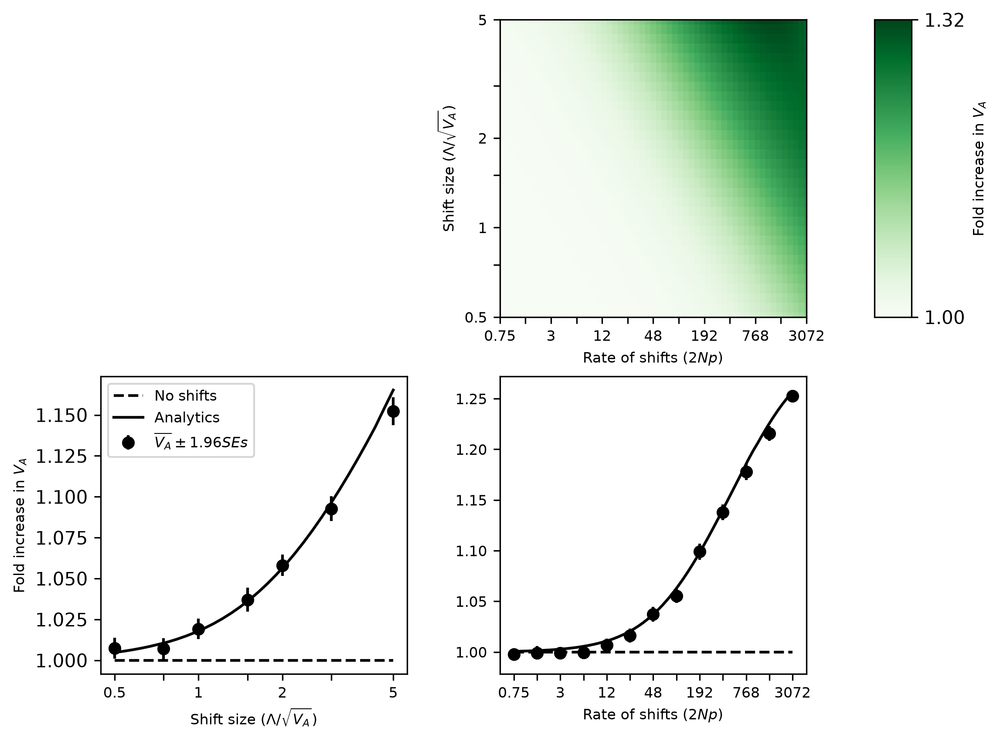

In [4]:
# the analytic V_A, in the Lande case
E2Ns = 1

fig = plt.figure(figsize=(8, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 1, 3], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[0, 0]).axis('off')
plt.subplot(gs[1, 4]).axis('off')
# make gs[0, 4] a colorbar
norm = colors.Normalize(vmin=analytic_V_A.min() / V_A(E2Ns=E2Ns), vmax=analytic_V_A.max() / V_A(E2Ns=E2Ns))
sm = plt.cm.ScalarMappable(cmap='Greens', norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 4]), orientation='vertical')
cbar.set_label(r'Fold increase in $V_A$', fontsize=fontsize)
cbar.ax.set_yticks([analytic_V_A.min() / V_A(E2Ns=E2Ns), analytic_V_A.max() / V_A(E2Ns=E2Ns)])
cbar.ax.set_yticklabels(['%.2f' % (analytic_V_A.min() / V_A(E2Ns=E2Ns)), '%.2f' % (analytic_V_A.max() / V_A(E2Ns=E2Ns))])
cbar.ax.minorticks_off()

# panel B: the effect of recurrent shifts on the analytic V_A
ax = plt.subplot(gs[0, 2])

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3, 5]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)
ax.pcolormesh(X, Y, np.divide(analytic_V_A, V_A(E2Ns=E2Ns)), cmap='Greens', norm=norm)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(shift_s0_list) % 2 == 1
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=[shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
ax.minorticks_off()

# panels C and D: the analytic V_A as a function of the shift size (or the rate of shifts) for a given rate of shifts (or shift size)
empirical_V_A_mean = np.zeros((7, 13))
empirical_V_A_se = np.zeros((7, 13))
for E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [(E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift) for E2Ns in [E2Ns, ] for index_shift_s0, shift_s0 in enumerate(shift_s0_list) for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)]:
    parallel_AA = 49
    var_ess_every_10N_generations = list()
    for i in range(1, 1 + parallel_AA):
        with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_nE_%d_empirical_average_V_A_%d/fixation_probability' % (round(E2Ns), 11, i), 'rb') as f:
            var_ess_every_10N_generations.extend(pickle.load(f)[3][10 * N::10 * N])
    empirical_V_A_mean[index_shift_s0][index_rate_of_shift] = np.mean(var_ess_every_10N_generations)
    empirical_V_A_se[index_shift_s0][index_rate_of_shift] = np.std(var_ess_every_10N_generations) / np.sqrt(np.size(var_ess_every_10N_generations))

ax = plt.subplot(gs[1, 0])
index_rate_of_shift, rate_of_shift = 28, 0.012
ax.plot(shift_s0_list, [1 for _ in shift_s0_list], 'k--', label='No shifts')
ax.plot(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), np.divide(analytic_V_A[:, index_rate_of_shift], V_A(E2Ns=E2Ns)), 'k-', label='Analytics')
ax.errorbar(shift_s0_list, np.divide(empirical_V_A_mean[:, np.searchsorted(rate_of_shifts_list, rate_of_shift)], V_A(E2Ns=E2Ns)), yerr=1.96 * np.divide(empirical_V_A_se[:, np.searchsorted(rate_of_shifts_list, rate_of_shift)], V_A(E2Ns=E2Ns)), fmt='o', color='k', label=r'$\overline{V_A} \pm 1.96SEs$')
ax.set_xscale('log')
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel(r'Fold increase in $V_A$', fontsize=fontsize)
ax.set_xticks(ticks=shift_s0_list, labels=[shift_s0 if index_shift_s0 % 2 == 0 else None for index_shift_s0, shift_s0 in enumerate(shift_s0_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
index_shift_s0, shift_s0 = 15, 1.5
ax.plot(2 * N * np.array(rate_of_shifts_list), [1 for _ in rate_of_shifts_list], 'k--', label='No shifts')
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), np.divide(analytic_V_A[index_shift_s0], V_A(E2Ns=E2Ns)), 'k-', label='Analytics')
ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.divide(empirical_V_A_mean[np.searchsorted(shift_s0_list, shift_s0)], V_A(E2Ns=E2Ns)), yerr=1.96 * np.divide(empirical_V_A_se[np.searchsorted(shift_s0_list, shift_s0)], V_A(E2Ns=E2Ns)), fmt='o', color='k', label=r'$\overline{V_A} \pm 1.96SEs$')
ax.set_xscale('log')
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

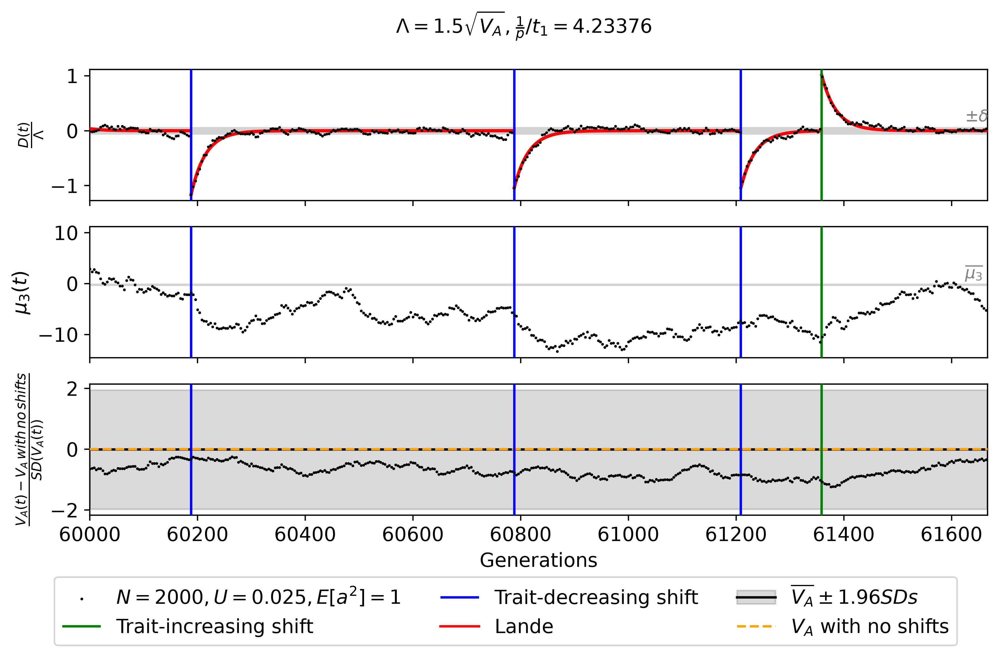

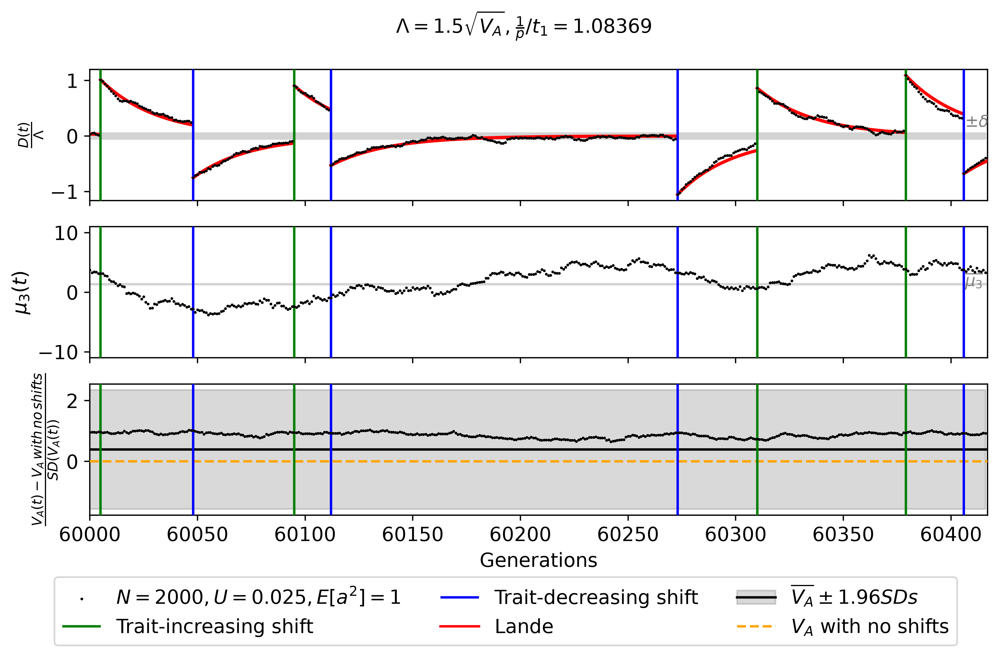

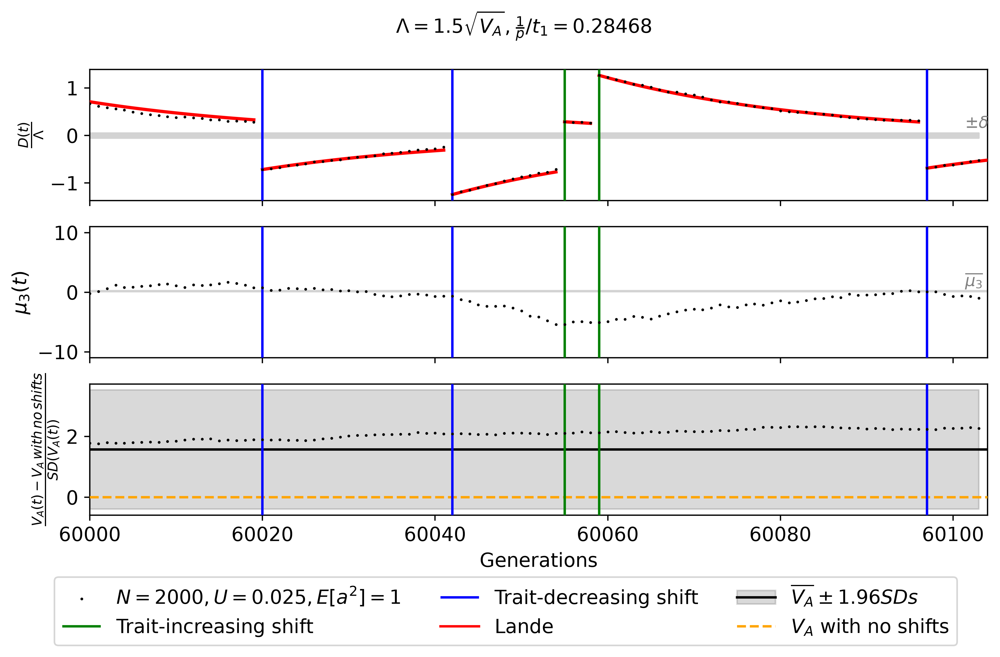

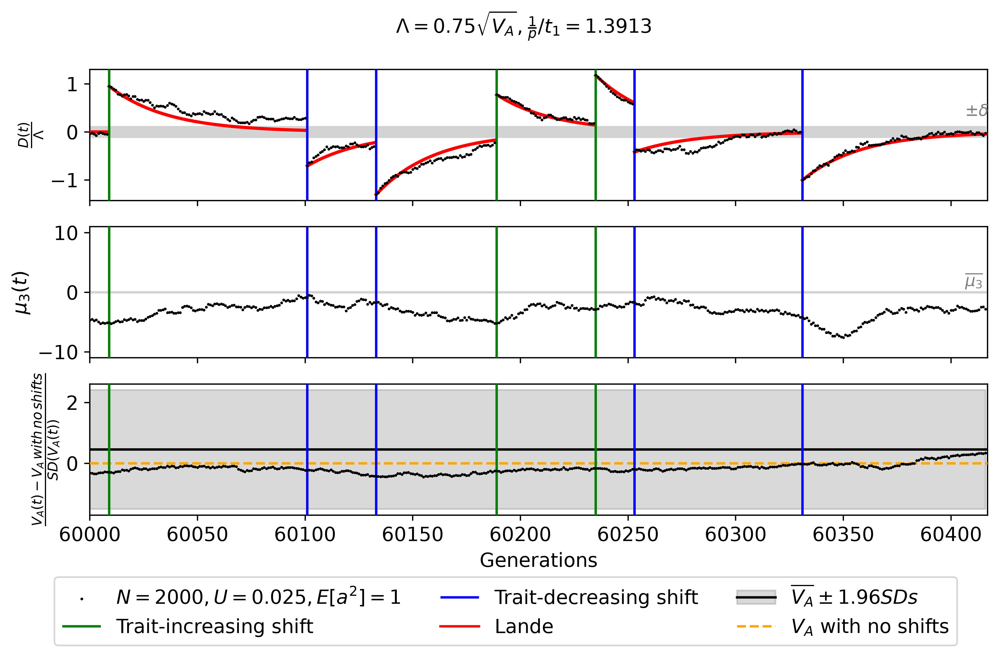

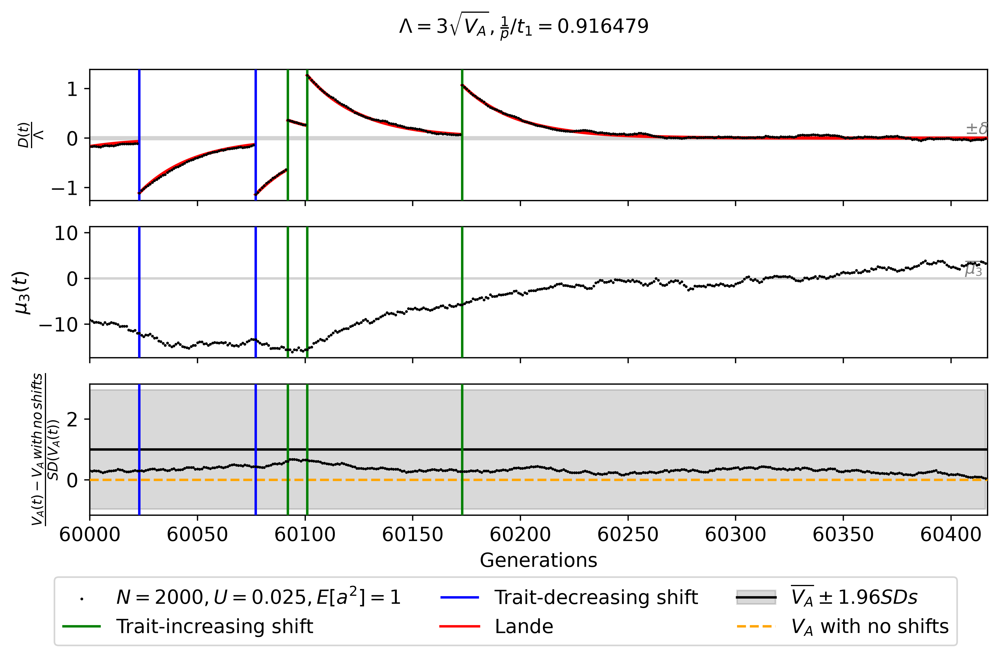

In [4]:
# D(t) in units of the shift size, \mu_3(t), and (V_A(t) - V_A under no shifts) / stdev(V_A(t)), in the Lande case
# ~5 shifts
from math import ceil
for E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [(E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift) for E2Ns in [1, ] for index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [[3, 1.5, 4, 0.003], [3, 1.5, 6, 0.012], [3, 1.5, 8, 0.048], [1, 0.75, 6, 0.012], [5, 3, 6, 0.012]]]:
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_2000_U_0_025_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_nE_100_empirical_average_V_A_1/fixation_probability' % round(E2Ns), 'rb') as f:
        dist_ess_over_time, var_ess_over_time, mu3_over_time = pickle.load(f)[2:5]
    
    fig = plt.figure(figsize=(10, 5), dpi=400)
    axs = fig.subplots(3, 1, sharex=True)
    
    start_plot_time = 30 * N
    end_plot_time = 30 * N + round(5 / rate_of_shift)
    start_time = start_plot_time - round(5 / rate_of_shift)
    end_time = end_plot_time + round(5 / rate_of_shift)
    
    for ax,data_temp in zip(axs,[dist_ess_over_time,mu3_over_time,var_ess_over_time]):
        
        ### plotting the data
        number_of_generations = end_plot_time - start_plot_time
        max_points = 500
        skip = ceil(number_of_generations/max_points)
        
        plotting_data = data_temp[start_plot_time:end_plot_time:skip]
        plotting_time = list(range(start_plot_time, end_plot_time))[::skip]
        max_y = max(data_temp[start_plot_time:end_plot_time])
        min_y = min(data_temp[start_plot_time:end_plot_time])
        
        ### plotting analytics and extra stuff
        if ax == axs[0]: # this is the distance
            ax.scatter(plotting_time,[dist_ess / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])) for dist_ess in dist_ess_over_time[start_plot_time:end_plot_time:skip]], zorder=10,marker='.',color='k',s=2)
            shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(start_time, end_time) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
            for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
                ax.plot(range(abs(shift_time_directional), abs(next_shift_time_directional)), [dist_ess_over_time[abs(shift_time_directional)] / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])) * np.exp(-empirical_average_V_A[index_shift_s0][index_rate_of_shift] / (2 * N) * (t - abs(shift_time_directional))) for t in range(abs(shift_time_directional),abs(next_shift_time_directional))], color='r', linewidth=2, zorder=5)
            ax.fill_between(x=range(start_plot_time, end_plot_time), y1=-1 / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])), y2=1 / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])), interpolate=True, color='lightgray', label=r'$\pm\delta$', zorder=0)
            ax.text(x = start_plot_time + (end_plot_time-start_plot_time)*0.975, y = 3 / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])), s = r'$\pm \delta$',color='gray')
            ax.set_ylabel(r'$\frac{D(t)}{\Lambda}$', fontsize=fontsize)
            
            max_y /= (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift]))
            min_y /= (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift]))
            
        elif ax == axs[2]: # this is the second moment
            ax.scatter(plotting_time,np.divide(np.subtract(plotting_data, V_A(E2Ns=E2Ns)), empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift]), zorder=10,marker='.',color='k',s=2)
            simulations = ax.scatter([], [], marker='.',color='k',s=2)
            trait_increasing = ax.vlines(x=np.nan,ymin=np.nan,ymax=np.nan,color='g')
            trait_decreasing = ax.vlines(x=np.nan,ymin=np.nan,ymax=np.nan,color='b')
            Lande, = ax.plot([], [], color='r')
            V_A_std = ax.fill_between(x=range(start_plot_time, end_plot_time), y1=(empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift] - 1.96, y2=(empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift] + 1.96, color='k', alpha=0.15, zorder=0)
            V_A_mean, = ax.plot([start_plot_time, end_plot_time], [(empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift]]*2, color='k', zorder=0)
            # analytic_V_A_root_finding = ax.hlines(y=(analytic_V_A[np.searchsorted(np.geomspace(0.5, 5, shift_s0_partitioning), shift_s0)][np.searchsorted(np.geomspace(0.0001875, 0.768, rate_of_shifts_partitioning), rate_of_shift)] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='orange', zorder=5)
            V_A_no_shifts = ax.hlines(y=0, xmin=start_plot_time, xmax=end_plot_time, colors='orange', zorder=5,ls='--')
            ax.set_ylabel(r'$\frac{V_A(t) - V_A\/with\/no\/shifts}{SD(V_A(t))}$', fontsize=fontsize)
                        
            min_y = min((min_y - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift], (empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift] - 1.96)
            max_y = max((max_y - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift], (empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift] + 1.96)

            min_y = min(min_y, 0)
            max_y = max(max_y, 0)
            
            ax.legend([simulations, trait_increasing, trait_decreasing, Lande, (V_A_std, V_A_mean), V_A_no_shifts], [r'$N=%d, U=%g, E[a^2]=%d$' % (N, U, round(E2Ns)), 'Trait-increasing shift', 'Trait-decreasing shift', 'Lande', r'$\overline{V_A} \pm 1.96SDs$', r'$V_A$ with no shifts'], loc='upper left', bbox_to_anchor=(-0.05, -0.4), fontsize=fontsize,ncols=3)
        
        elif ax == axs[1]: # this is the third moment
            pass
            ax.scatter(plotting_time,plotting_data, zorder=10,marker='.',color='k',s=2)
            ax.hlines(y=empirical_average_mu3_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='lightgray', zorder=0)
            ax.text(x = start_plot_time + (end_plot_time-start_plot_time)*0.975, y = 1, s = r'$\overline{\mu_{3}}$',color='gray')
            ax.set_ylabel(r'$\mu_3 (t)$', fontsize=fontsize)
            
            min_y = min(min_y, empirical_average_mu3_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift])
            max_y = max(max_y, empirical_average_mu3_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift])
            
            min_y = min(min_y, -10)
            max_y = max(max_y, 10)
            
        ### things to do after plotting everything else
        min_y_limit = min_y-(max_y - min_y)/20
        max_y_limit = max_y+(max_y - min_y)/20
        
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])], ymin=min_y_limit, ymax=max_y_limit, colors='g', zorder=5)
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])], ymin=min_y_limit, ymax=max_y_limit, colors='b', zorder=5)
        
        ax.set_ylim([min_y_limit,max_y_limit])
        
        ax.set_xlim([start_plot_time,end_plot_time])
        ax.tick_params(axis='y', labelsize=fontsize)
        
        
#     axs[0].scatter(range(start_time, end_time), dist_ess_over_time[start_time:end_time], zorder=10,marker='.',color='k')
#     shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(start_time, end_time) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
#     for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
#         t_1 = 2 * N / empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] * np.log(abs(dist_ess_over_time[abs(shift_time_directional)]))
#         axs[0].plot(range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))), [dist_ess_over_time[abs(shift_time_directional)] * np.exp(-empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] / (2 * N) * (t - abs(shift_time_directional))) for t in range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)))], color='r', linewidth=5, zorder=5)
#         if abs(next_shift_time_directional) > abs(shift_time_directional) + round(t_1):
#             axs[0].plot(range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)), [mu3_over_time[t] / (2 * var_ess_over_time[t]) for t in range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))], color='k', linewidth=5, zorder=5)
# #     axs[0].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(dist_ess_over_time[start_time:end_time]), ymax=max(dist_ess_over_time[start_time:end_time]), colors='g', zorder=5)
# #     axs[0].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(dist_ess_over_time[start_time:end_time]), ymax=max(dist_ess_over_time[start_time:end_time]), colors='b', zorder=5)
#     axs[0].fill_between(x=range(start_time, end_time), y1=-1, y2=1, interpolate=True, color='lightgray', label=r'$\pm\delta$', zorder=0)
#     axs[0].plot([], [], color='r', label='Lande')
#     axs[0].plot([], [], color='k', label='QS')
#     axs[0].set_ylabel(r'$D(t)$', fontsize=fontsize)
#     axs[0].tick_params(axis='y', labelsize=fontsize)
#     axs[0].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
    
# #     axs[2].scatter(range(start_time, end_time), var_ess_over_time[start_time:end_time], zorder=10,marker='.',color='k')
#     axs[2].fill_between(x=range(start_time, end_time), y1=empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], y2=empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] + 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], color='lightgray', alpha=0.5, label=r'$\overline{V_A}$', zorder=0)
#     axs[2].plot([start_time, end_time], [empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]]*2, color='lightgray', label=r'$\overline{V_A}$', zorder=0)
#     axs[2].hlines(y=empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='r', label=r'$\overline{V_A} w.r.t. (\Delta x_d^{nL})^2$', zorder=5)
#     axs[2].hlines(y=analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='k', label=r'$V_A(V_A\/under\/no\/shifts)$', zorder=5)
#     axs[2].hlines(y=V_A(E2Ns=16), xmin=start_time, xmax=end_time, colors='w', label=r'$V_A\/under\/no\/shifts$', zorder=5)
# #     axs[2].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(var_ess_over_time[start_time:end_time]), ymax=max(var_ess_over_time[start_time:end_time]), colors='g', zorder=5)
# #     axs[2].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(var_ess_over_time[start_time:end_time]), ymax=max(var_ess_over_time[start_time:end_time]), colors='b', zorder=5)
#     axs[2].set_ylabel(r'$V_A(t)$', fontsize=fontsize)
#     axs[2].tick_params(axis='y', labelsize=fontsize)
#     axs[2].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
    
# #     axs[1].scatter(range(start_time, end_time), mu3_over_time[start_time:end_time], zorder=10, marker='.',color='k')
#     axs[1].hlines(y=empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='lightgray', label=r'$\overline{\mu_3}$', zorder=0)
# #     axs[1].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(mu3_over_time[start_time:end_time]), ymax=max(mu3_over_time[start_time:end_time]), colors='g', label='Trait-increasing', zorder=5)
# #     axs[1].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(mu3_over_time[start_time:end_time]), ymax=max(mu3_over_time[start_time:end_time]), colors='b', label='Trait-decreasing', zorder=5)
#     axs[1].set_ylabel(r'$\mu_3(t)$', fontsize=fontsize)
#     axs[1].tick_params(axis='y', labelsize=fontsize)
#     axs[1].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
        
    plt.xlabel('Generations', fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    t_1 = 2 * N / empirical_average_V_A[index_shift_s0][index_rate_of_shift] * np.log(shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift]))
    plt.suptitle(r'$\Lambda=%g\sqrt{V_A}, \frac{1}{p} / t_1=%g$' % (shift_s0, 1.0 / rate_of_shift / t_1), fontsize=fontsize)
    plt.show()

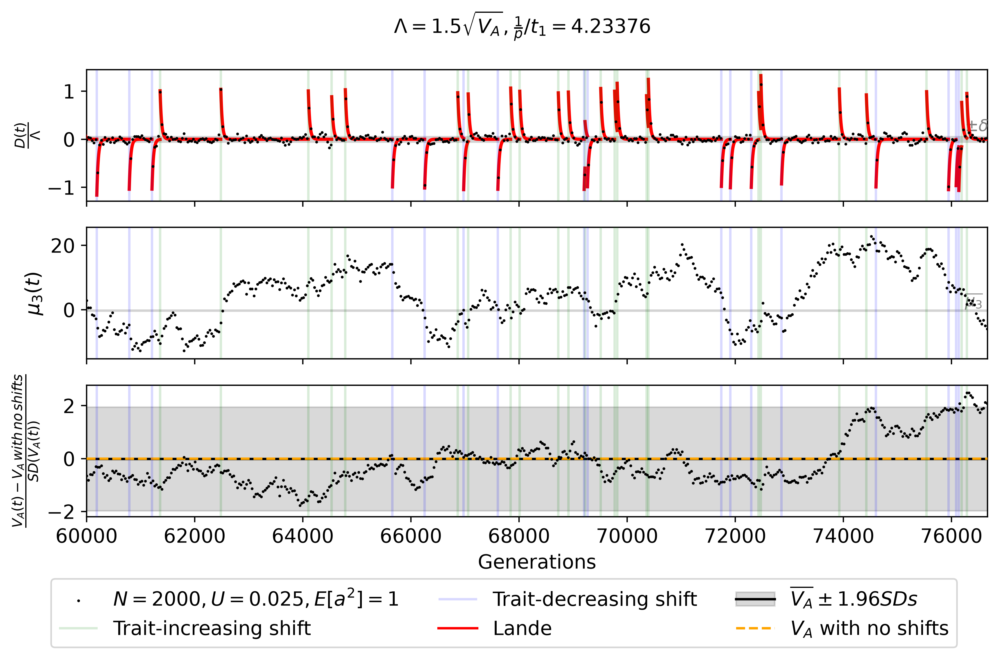

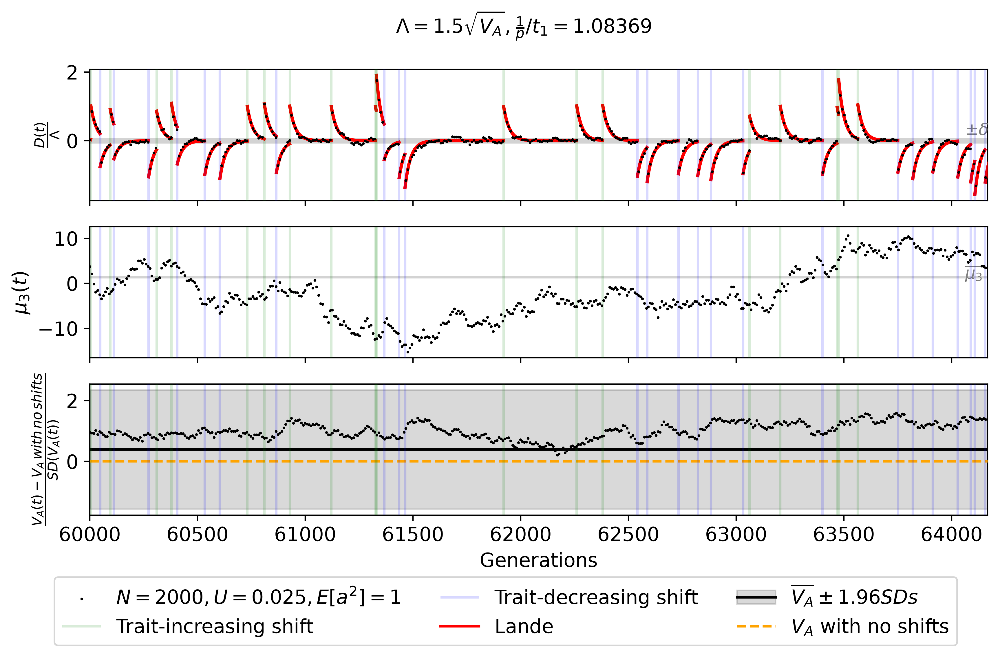

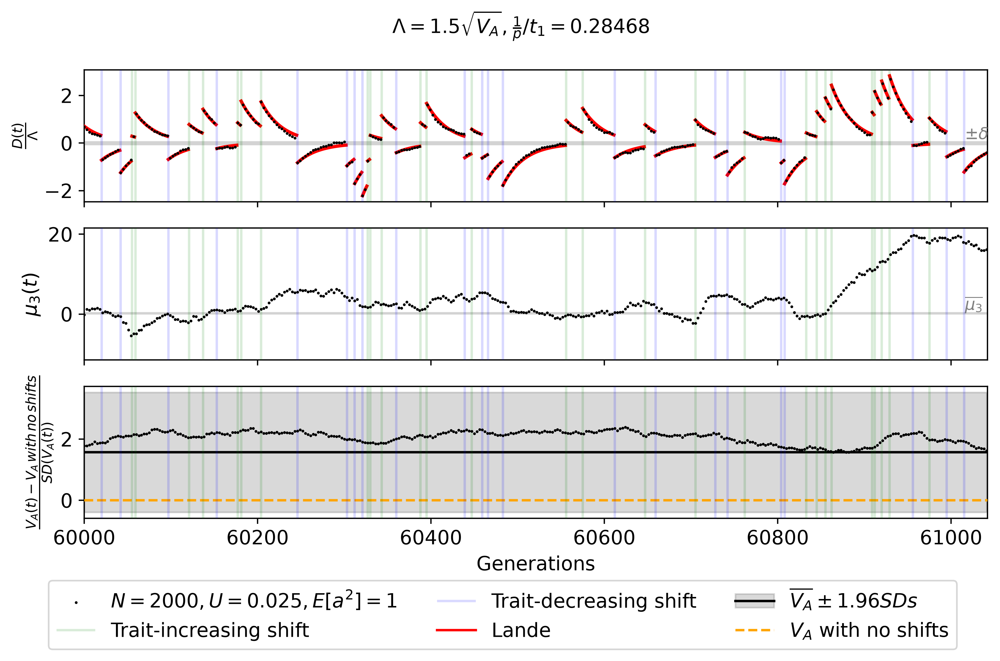

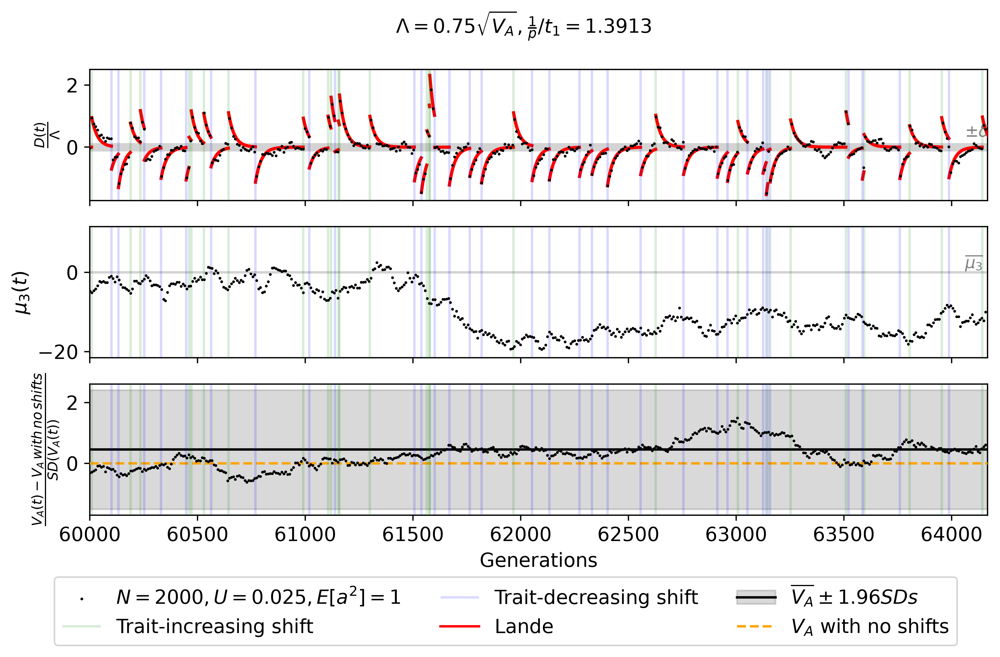

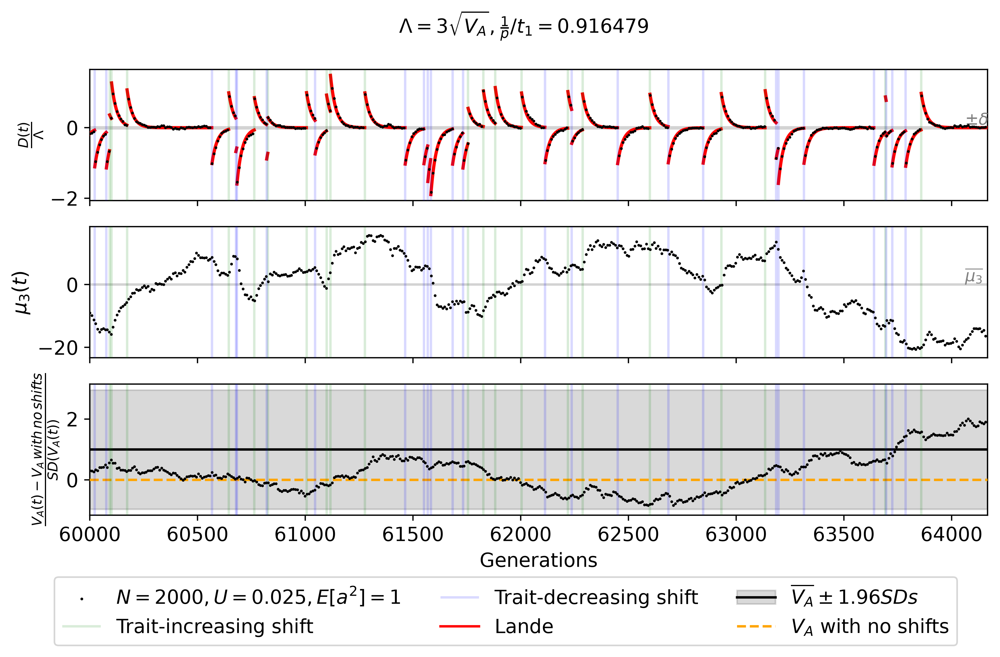

In [5]:
# ~50 shifts
from math import ceil
for E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [(E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift) for E2Ns in [1, ] for index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [[3, 1.5, 4, 0.003], [3, 1.5, 6, 0.012], [3, 1.5, 8, 0.048], [1, 0.75, 6, 0.012], [5, 3, 6, 0.012]]]:
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_2000_U_0_025_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_nE_100_empirical_average_V_A_1/fixation_probability' % round(E2Ns), 'rb') as f:
        dist_ess_over_time, var_ess_over_time, mu3_over_time = pickle.load(f)[2:5]
    
    fig = plt.figure(figsize=(10, 5), dpi=400)
    axs = fig.subplots(3, 1, sharex=True)
    
    start_plot_time = 30 * N
    end_plot_time = 30 * N + round(50 / rate_of_shift)
    start_time = start_plot_time - round(5 / rate_of_shift)
    end_time = end_plot_time + round(5 / rate_of_shift)
    
    for ax,data_temp in zip(axs,[dist_ess_over_time,mu3_over_time,var_ess_over_time]):
        
        ### plotting the data
        number_of_generations = end_plot_time - start_plot_time
        max_points = 500
        skip = ceil(number_of_generations/max_points)
        
        plotting_data = data_temp[start_plot_time:end_plot_time:skip]
        plotting_time = list(range(start_plot_time, end_plot_time))[::skip]
        max_y = max(data_temp[start_plot_time:end_plot_time])
        min_y = min(data_temp[start_plot_time:end_plot_time])
        
        ### plotting analytics and extra stuff
        if ax == axs[0]: # this is the distance
            ax.scatter(plotting_time,[dist_ess / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])) for dist_ess in dist_ess_over_time[start_plot_time:end_plot_time:skip]], zorder=10,marker='.',color='k',s=2)
            shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(start_time, end_time) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
            for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
                ax.plot(range(abs(shift_time_directional), abs(next_shift_time_directional)), [dist_ess_over_time[abs(shift_time_directional)] / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])) * np.exp(-empirical_average_V_A[index_shift_s0][index_rate_of_shift] / (2 * N) * (t - abs(shift_time_directional))) for t in range(abs(shift_time_directional),abs(next_shift_time_directional))], color='r', linewidth=2, zorder=5)
            ax.fill_between(x=range(start_plot_time, end_plot_time), y1=-1 / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])), y2=1 / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])), interpolate=True, color='lightgray', label=r'$\pm\delta$', zorder=0)
            ax.text(x = start_plot_time + (end_plot_time-start_plot_time)*0.975, y = 3 / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])), s = r'$\pm \delta$',color='gray')
            ax.set_ylabel(r'$\frac{D(t)}{\Lambda}$', fontsize=fontsize)
            
            max_y /= (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift]))
            min_y /= (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift]))
            
        elif ax == axs[2]: # this is the second moment
            ax.scatter(plotting_time,np.divide(np.subtract(plotting_data, V_A(E2Ns=E2Ns)), empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift]), zorder=10,marker='.',color='k',s=2)
            simulations = ax.scatter([], [], marker='.',color='k',s=2)
            trait_increasing = ax.vlines(x=np.nan,ymin=np.nan,ymax=np.nan,color='g',alpha=0.15)
            trait_decreasing = ax.vlines(x=np.nan,ymin=np.nan,ymax=np.nan,color='b',alpha=0.15)
            Lande, = ax.plot([], [], color='r')
            V_A_std = ax.fill_between(x=range(start_plot_time, end_plot_time), y1=(empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift] - 1.96, y2=(empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift] + 1.96, color='k', alpha=0.15, zorder=0)
            V_A_mean, = ax.plot([start_plot_time, end_plot_time], [(empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift]]*2, color='k', zorder=0)
            # analytic_V_A_root_finding = ax.hlines(y=(analytic_V_A[np.searchsorted(np.geomspace(0.5, 5, shift_s0_partitioning), shift_s0)][np.searchsorted(np.geomspace(0.0001875, 0.768, rate_of_shifts_partitioning), rate_of_shift)] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='orange', zorder=5)
            V_A_no_shifts = ax.hlines(y=0, xmin=start_plot_time, xmax=end_plot_time, colors='orange', zorder=5,ls='--')
            ax.set_ylabel(r'$\frac{V_A(t) - V_A\/with\/no\/shifts}{SD(V_A(t))}$', fontsize=fontsize)
                        
            min_y = min((min_y - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift], (empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift] - 1.96)
            max_y = max((max_y - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift], (empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift] + 1.96)

            min_y = min(min_y, 0)
            max_y = max(max_y, 0)
            
            ax.legend([simulations, trait_increasing, trait_decreasing, Lande, (V_A_std, V_A_mean), V_A_no_shifts], [r'$N=%d, U=%g, E[a^2]=%d$' % (N, U, round(E2Ns)), 'Trait-increasing shift', 'Trait-decreasing shift', 'Lande', r'$\overline{V_A} \pm 1.96SDs$', r'$V_A$ with no shifts'], loc='upper left', bbox_to_anchor=(-0.05, -0.4), fontsize=fontsize,ncols=3)
        
        elif ax == axs[1]: # this is the third moment
            pass
            ax.scatter(plotting_time,plotting_data, zorder=10,marker='.',color='k',s=2)
            ax.hlines(y=empirical_average_mu3_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='lightgray', zorder=0)
            ax.text(x = start_plot_time + (end_plot_time-start_plot_time)*0.975, y = 1, s = r'$\overline{\mu_{3}}$',color='gray')
            ax.set_ylabel(r'$\mu_3 (t)$', fontsize=fontsize)
            
            min_y = min(min_y, empirical_average_mu3_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift])
            max_y = max(max_y, empirical_average_mu3_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift])
            
            min_y = min(min_y, -10)
            max_y = max(max_y, 10)
            
        ### things to do after plotting everything else
        min_y_limit = min_y-(max_y - min_y)/20
        max_y_limit = max_y+(max_y - min_y)/20
        
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])], ymin=min_y_limit, ymax=max_y_limit, colors='g', alpha=0.15, zorder=5)
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])], ymin=min_y_limit, ymax=max_y_limit, colors='b', alpha=0.15, zorder=5)
        
        ax.set_ylim([min_y_limit,max_y_limit])
        
        ax.set_xlim([start_plot_time,end_plot_time])
        ax.tick_params(axis='y', labelsize=fontsize)
        
        
#     axs[0].scatter(range(start_time, end_time), dist_ess_over_time[start_time:end_time], zorder=10,marker='.',color='k')
#     shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(start_time, end_time) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
#     for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
#         t_1 = 2 * N / empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] * np.log(abs(dist_ess_over_time[abs(shift_time_directional)]))
#         axs[0].plot(range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))), [dist_ess_over_time[abs(shift_time_directional)] * np.exp(-empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] / (2 * N) * (t - abs(shift_time_directional))) for t in range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)))], color='r', linewidth=5, zorder=5)
#         if abs(next_shift_time_directional) > abs(shift_time_directional) + round(t_1):
#             axs[0].plot(range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)), [mu3_over_time[t] / (2 * var_ess_over_time[t]) for t in range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))], color='k', linewidth=5, zorder=5)
# #     axs[0].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(dist_ess_over_time[start_time:end_time]), ymax=max(dist_ess_over_time[start_time:end_time]), colors='g', zorder=5)
# #     axs[0].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(dist_ess_over_time[start_time:end_time]), ymax=max(dist_ess_over_time[start_time:end_time]), colors='b', zorder=5)
#     axs[0].fill_between(x=range(start_time, end_time), y1=-1, y2=1, interpolate=True, color='lightgray', label=r'$\pm\delta$', zorder=0)
#     axs[0].plot([], [], color='r', label='Lande')
#     axs[0].plot([], [], color='k', label='QS')
#     axs[0].set_ylabel(r'$D(t)$', fontsize=fontsize)
#     axs[0].tick_params(axis='y', labelsize=fontsize)
#     axs[0].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
    
# #     axs[2].scatter(range(start_time, end_time), var_ess_over_time[start_time:end_time], zorder=10,marker='.',color='k')
#     axs[2].fill_between(x=range(start_time, end_time), y1=empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], y2=empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] + 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], color='lightgray', alpha=0.5, label=r'$\overline{V_A}$', zorder=0)
#     axs[2].plot([start_time, end_time], [empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]]*2, color='lightgray', label=r'$\overline{V_A}$', zorder=0)
#     axs[2].hlines(y=empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='r', label=r'$\overline{V_A} w.r.t. (\Delta x_d^{nL})^2$', zorder=5)
#     axs[2].hlines(y=analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='k', label=r'$V_A(V_A\/under\/no\/shifts)$', zorder=5)
#     axs[2].hlines(y=V_A(E2Ns=16), xmin=start_time, xmax=end_time, colors='w', label=r'$V_A\/under\/no\/shifts$', zorder=5)
# #     axs[2].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(var_ess_over_time[start_time:end_time]), ymax=max(var_ess_over_time[start_time:end_time]), colors='g', zorder=5)
# #     axs[2].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(var_ess_over_time[start_time:end_time]), ymax=max(var_ess_over_time[start_time:end_time]), colors='b', zorder=5)
#     axs[2].set_ylabel(r'$V_A(t)$', fontsize=fontsize)
#     axs[2].tick_params(axis='y', labelsize=fontsize)
#     axs[2].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
    
# #     axs[1].scatter(range(start_time, end_time), mu3_over_time[start_time:end_time], zorder=10, marker='.',color='k')
#     axs[1].hlines(y=empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='lightgray', label=r'$\overline{\mu_3}$', zorder=0)
# #     axs[1].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(mu3_over_time[start_time:end_time]), ymax=max(mu3_over_time[start_time:end_time]), colors='g', label='Trait-increasing', zorder=5)
# #     axs[1].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(mu3_over_time[start_time:end_time]), ymax=max(mu3_over_time[start_time:end_time]), colors='b', label='Trait-decreasing', zorder=5)
#     axs[1].set_ylabel(r'$\mu_3(t)$', fontsize=fontsize)
#     axs[1].tick_params(axis='y', labelsize=fontsize)
#     axs[1].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
        
    plt.xlabel('Generations', fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    t_1 = 2 * N / empirical_average_V_A[index_shift_s0][index_rate_of_shift] * np.log(shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift]))
    plt.suptitle(r'$\Lambda=%g\sqrt{V_A}, \frac{1}{p} / t_1=%g$' % (shift_s0, 1.0 / rate_of_shift / t_1), fontsize=fontsize)
    plt.show()

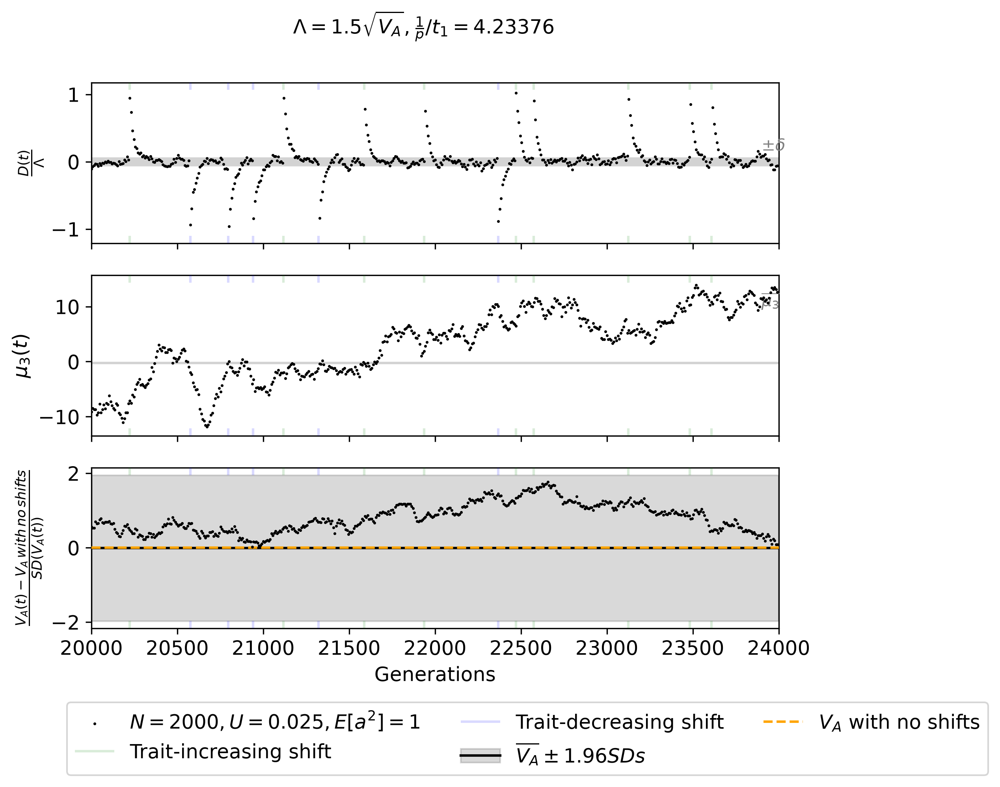

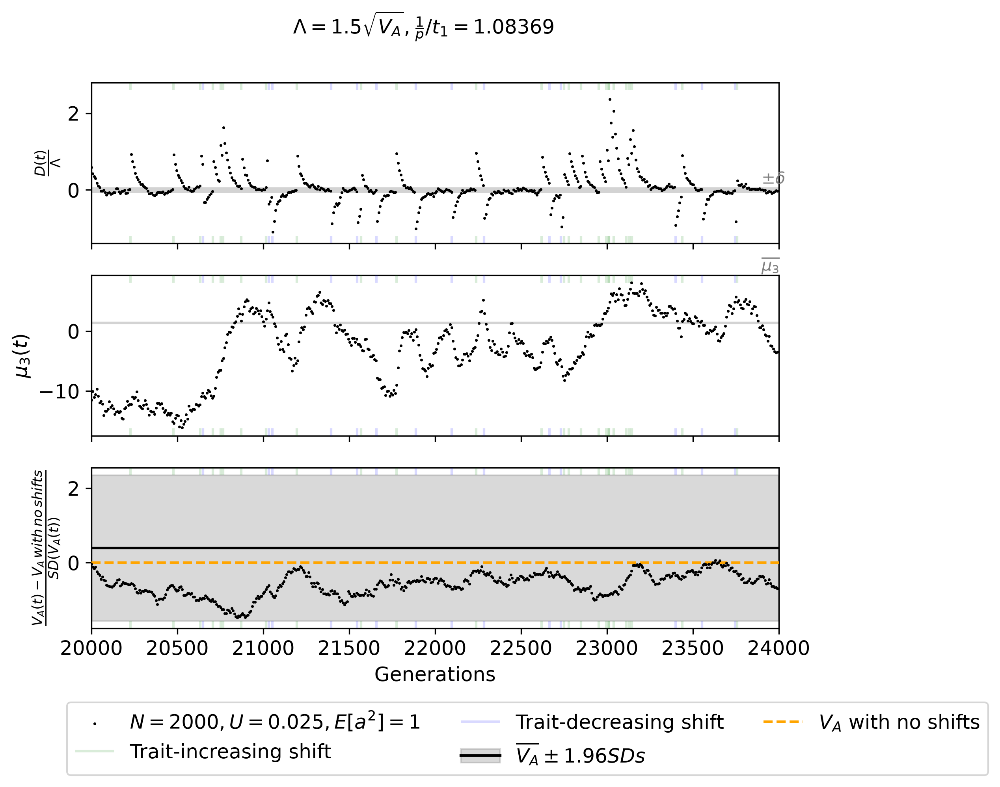

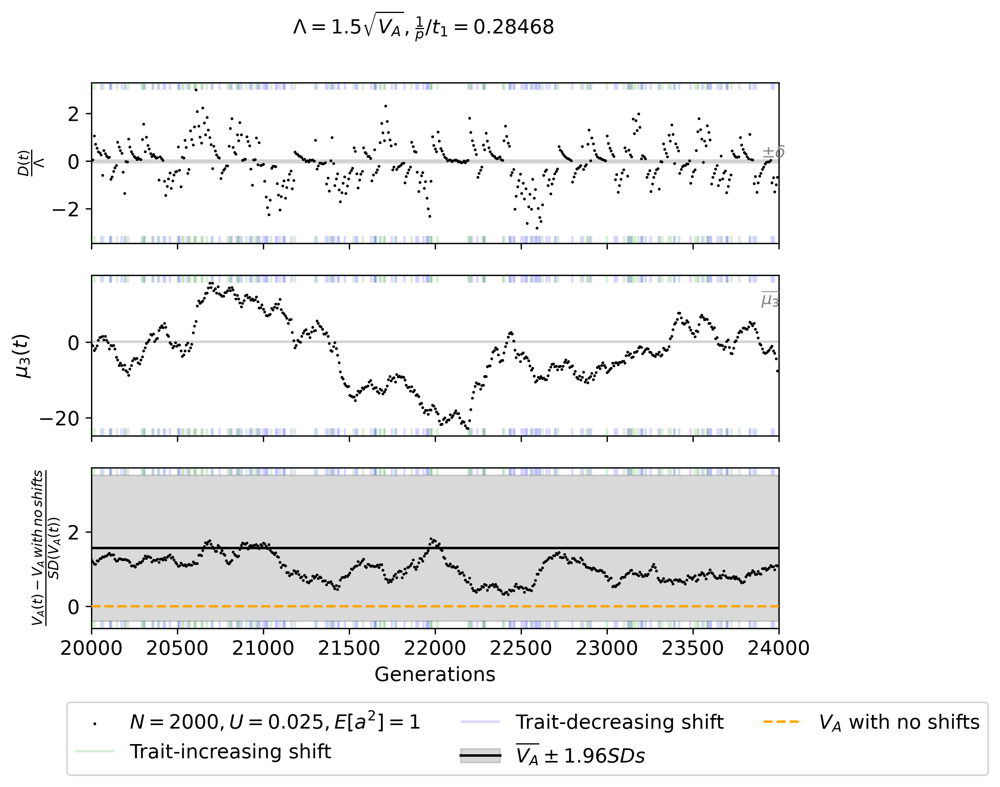

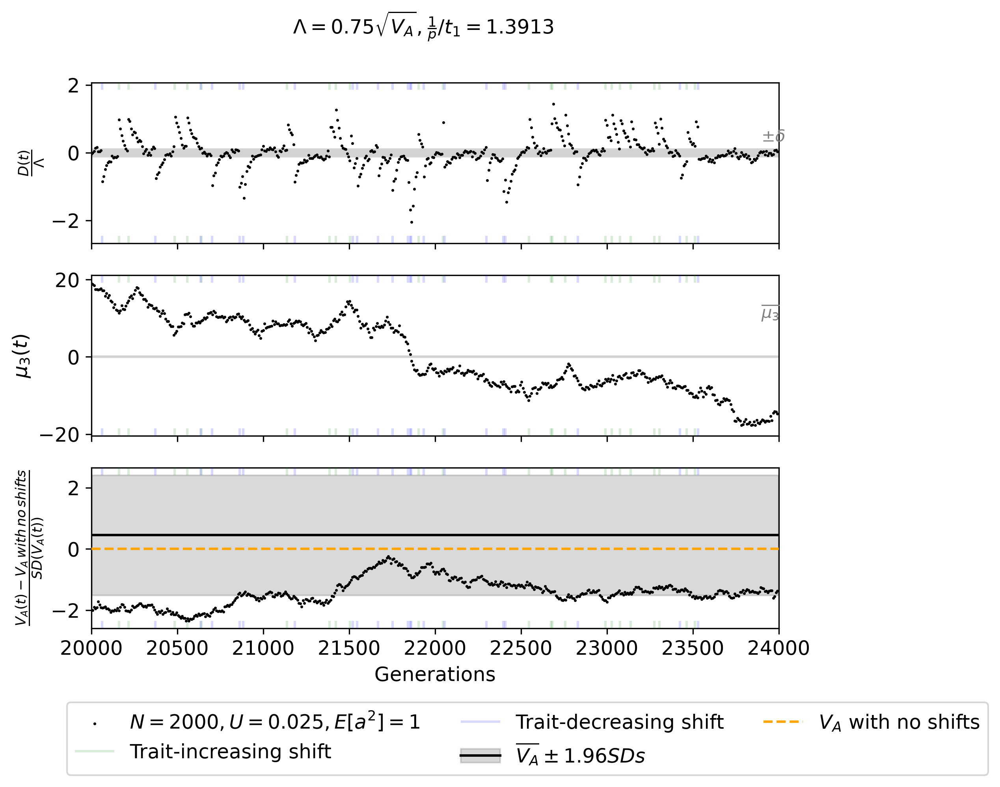

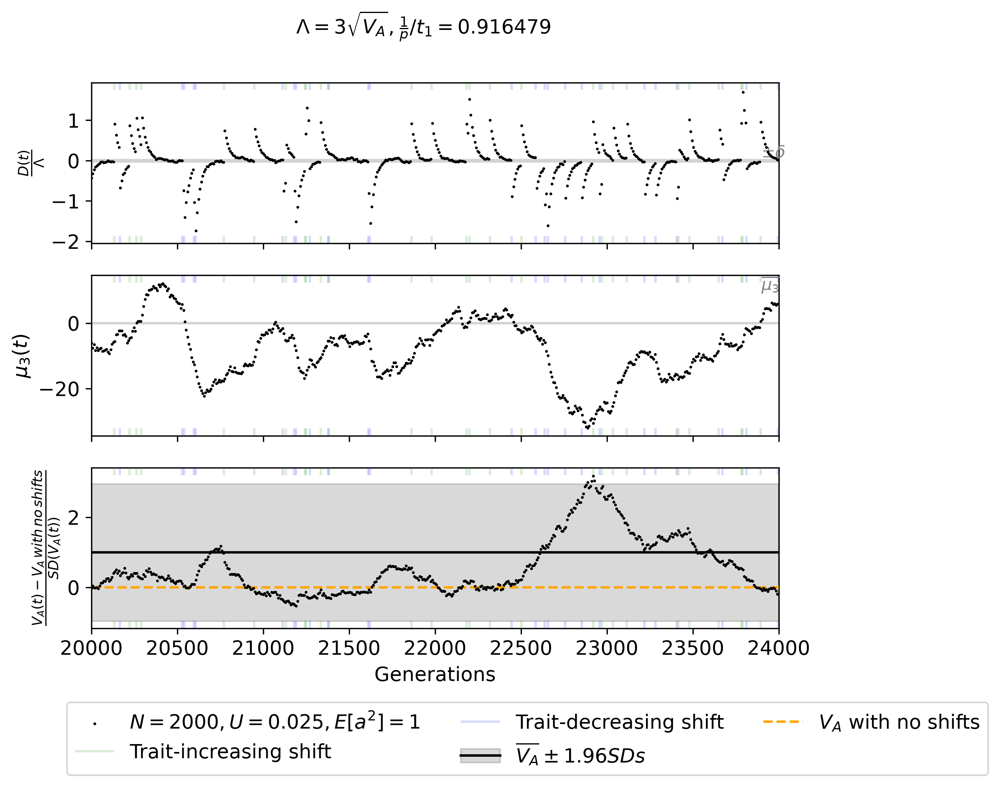

In [6]:
# 2N generations
from math import ceil
E2Ns = 1

shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

for E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [(E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift) for E2Ns in [1, ] for index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [[3, 1.5, 4, 0.003], [3, 1.5, 6, 0.012], [3, 1.5, 8, 0.048], [1, 0.75, 6, 0.012], [5, 3, 6, 0.012]]]:
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_2000_U_0_025_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_nE_100_empirical_average_V_A_1/fixation_probability' % round(E2Ns), 'rb') as f:
        dist_ess_over_time, var_ess_over_time, mu3_over_time = pickle.load(f)[2:5]
    
    fig = plt.figure(figsize=(7.5, 6), dpi=300)
    axs = fig.subplots(3, 1, sharex=True)
    
    start_plot_time = 10 * N
    end_plot_time = start_plot_time + 2 * N
    start_time = start_plot_time - round(5 / rate_of_shift)
    end_time = end_plot_time + round(5 / rate_of_shift)
    
    for ax,data_temp in zip(axs,[dist_ess_over_time,mu3_over_time,var_ess_over_time]):
        
        ### plotting the data
        number_of_generations = end_plot_time - start_plot_time
        max_points = 500
        skip = ceil(number_of_generations/max_points)
        
        plotting_data = data_temp[start_plot_time:end_plot_time:skip]
        plotting_time = list(range(start_plot_time, end_plot_time))[::skip]
        max_y = max(data_temp[start_plot_time:end_plot_time])
        min_y = min(data_temp[start_plot_time:end_plot_time])
        
        ### plotting analytics and extra stuff
        if ax == axs[0]: # this is the distance
            ax.scatter(plotting_time,[dist_ess / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])) for dist_ess in dist_ess_over_time[start_plot_time:end_plot_time:skip]], zorder=10,marker='.',color='k',s=2)
            # shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(start_time, end_time) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
            # for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
            #     ax.plot(range(abs(shift_time_directional), abs(next_shift_time_directional)), [dist_ess_over_time[abs(shift_time_directional)] / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])) * np.exp(-empirical_average_V_A[index_shift_s0][index_rate_of_shift] / (2 * N) * (t - abs(shift_time_directional))) for t in range(abs(shift_time_directional),abs(next_shift_time_directional))], color='r', linewidth=2, zorder=5)
            ax.fill_between(x=range(start_plot_time, end_plot_time), y1=-1 / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])), y2=1 / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])), interpolate=True, color='lightgray', label=r'$\pm\delta$', zorder=0)
            ax.text(x = start_plot_time + (end_plot_time-start_plot_time)*0.975, y = 3 / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])), s = r'$\pm \delta$',color='gray')
            ax.set_ylabel(r'$\frac{D(t)}{\Lambda}$', fontsize=fontsize)
            
            max_y /= (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift]))
            min_y /= (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift]))
            
        elif ax == axs[2]: # this is the second moment
            ax.scatter(plotting_time,np.divide(np.subtract(plotting_data, V_A(E2Ns=E2Ns)), empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift]), zorder=10,marker='.',color='k',s=2)
            simulations = ax.scatter([], [], marker='.',color='k',s=2)
            trait_increasing = ax.vlines(x=np.nan,ymin=np.nan,ymax=np.nan,color='g',alpha=0.15)
            trait_decreasing = ax.vlines(x=np.nan,ymin=np.nan,ymax=np.nan,color='b',alpha=0.15)
            # Lande, = ax.plot([], [], color='r')
            V_A_std = ax.fill_between(x=range(start_plot_time, end_plot_time), y1=(empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift] - 1.96, y2=(empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift] + 1.96, color='k', alpha=0.15, zorder=0)
            V_A_mean, = ax.plot([start_plot_time, end_plot_time], [(empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift]]*2, color='k', zorder=0)
            # analytic_V_A_root_finding = ax.hlines(y=(analytic_V_A[np.searchsorted(np.geomspace(0.5, 5, shift_s0_partitioning), shift_s0)][np.searchsorted(np.geomspace(0.0001875, 0.768, rate_of_shifts_partitioning), rate_of_shift)] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='orange', zorder=5)
            V_A_no_shifts = ax.hlines(y=0, xmin=start_plot_time, xmax=end_plot_time, colors='orange', zorder=5,ls='--')
            ax.set_ylabel(r'$\frac{V_A(t) - V_A\/with\/no\/shifts}{SD(V_A(t))}$', fontsize=fontsize)
            
            # min_y = min(min_y,(empirical_average_V_A[index_shift_s0][index_rate_of_shift] - 1.96 * empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift]))
            # max_y = max(max_y,(empirical_average_V_A[index_shift_s0][index_rate_of_shift] + 1.96 * empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift]))

            # min_y = min(min_y,V_A(E2Ns=E2Ns))
            # max_y = max(max_y,V_A(E2Ns=E2Ns))
            
            min_y = min((min_y - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift], (empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift] - 1.96)
            max_y = max((max_y - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift], (empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift] + 1.96)

            min_y = min(min_y, 0)
            max_y = max(max_y, 0)
            
            ax.legend([simulations, trait_increasing, trait_decreasing, (V_A_std, V_A_mean), V_A_no_shifts], [r'$N=%d, U=%g, E[a^2]=%d$' % (N, U, round(E2Ns)), 'Trait-increasing shift', 'Trait-decreasing shift', r'$\overline{V_A} \pm 1.96SDs$', r'$V_A$ with no shifts'], loc='upper left', bbox_to_anchor=(-0.05, -0.4), fontsize=fontsize,ncols=3)
            
        elif ax == axs[1]: # this is the third moment
            ax.scatter(plotting_time,plotting_data, zorder=10,marker='.',color='k',s=2)
            ax.hlines(y=empirical_average_mu3_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='lightgray', zorder=0)
            ax.text(x = start_plot_time + (end_plot_time-start_plot_time)*0.975, y = 10, s = r'$\overline{\mu_{3}}$',color='gray')
            ax.set_ylabel(r'$\mu_3 (t)$', fontsize=fontsize)
            
            min_y = min(min_y, empirical_average_mu3_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift])
            max_y = max(max_y, empirical_average_mu3_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift])
        
        ### things to do after plotting everything else
        min_y_limit = min_y-(max_y - min_y)/20
        max_y_limit = max_y+(max_y - min_y)/20
        
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])], ymin=min_y_limit, ymax=min_y, colors='g', alpha=0.15, zorder=5)
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])], ymin=max_y, ymax=max_y_limit, colors='g', alpha=0.15, zorder=5)
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])], ymin=min_y_limit, ymax=min_y, colors='b', alpha=0.15, zorder=5)
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])], ymin=max_y, ymax=max_y_limit, colors='b', alpha=0.15, zorder=5)
        
        ax.set_ylim([min_y_limit,max_y_limit])
        
        ax.set_xlim([start_plot_time,end_plot_time])
        ax.tick_params(axis='y', labelsize=fontsize)
        
        
#     axs[0].scatter(range(start_time, end_time), dist_ess_over_time[start_time:end_time], zorder=10,marker='.',color='k')
#     shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(start_time, end_time) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
#     for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
#         t_1 = 2 * N / empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] * np.log(abs(dist_ess_over_time[abs(shift_time_directional)]))
#         axs[0].plot(range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))), [dist_ess_over_time[abs(shift_time_directional)] * np.exp(-empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] / (2 * N) * (t - abs(shift_time_directional))) for t in range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)))], color='r', linewidth=5, zorder=5)
#         if abs(next_shift_time_directional) > abs(shift_time_directional) + round(t_1):
#             axs[0].plot(range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)), [mu3_over_time[t] / (2 * var_ess_over_time[t]) for t in range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))], color='k', linewidth=5, zorder=5)
# #     axs[0].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(dist_ess_over_time[start_time:end_time]), ymax=max(dist_ess_over_time[start_time:end_time]), colors='g', zorder=5)
# #     axs[0].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(dist_ess_over_time[start_time:end_time]), ymax=max(dist_ess_over_time[start_time:end_time]), colors='b', zorder=5)
#     axs[0].fill_between(x=range(start_time, end_time), y1=-1, y2=1, interpolate=True, color='lightgray', label=r'$\pm\delta$', zorder=0)
#     axs[0].plot([], [], color='r', label='Lande')
#     axs[0].plot([], [], color='k', label='QS')
#     axs[0].set_ylabel(r'$D(t)$', fontsize=fontsize)
#     axs[0].tick_params(axis='y', labelsize=fontsize)
#     axs[0].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
    
# #     axs[2].scatter(range(start_time, end_time), var_ess_over_time[start_time:end_time], zorder=10,marker='.',color='k')
#     axs[2].fill_between(x=range(start_time, end_time), y1=empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], y2=empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] + 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], color='lightgray', alpha=0.5, label=r'$\overline{V_A}$', zorder=0)
#     axs[2].plot([start_time, end_time], [empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]]*2, color='lightgray', label=r'$\overline{V_A}$', zorder=0)
#     axs[2].hlines(y=empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='r', label=r'$\overline{V_A} w.r.t. (\Delta x_d^{nL})^2$', zorder=5)
#     axs[2].hlines(y=analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='k', label=r'$V_A(V_A\/under\/no\/shifts)$', zorder=5)
#     axs[2].hlines(y=V_A(E2Ns=16), xmin=start_time, xmax=end_time, colors='w', label=r'$V_A\/under\/no\/shifts$', zorder=5)
# #     axs[2].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(var_ess_over_time[start_time:end_time]), ymax=max(var_ess_over_time[start_time:end_time]), colors='g', zorder=5)
# #     axs[2].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(var_ess_over_time[start_time:end_time]), ymax=max(var_ess_over_time[start_time:end_time]), colors='b', zorder=5)
#     axs[2].set_ylabel(r'$V_A(t)$', fontsize=fontsize)
#     axs[2].tick_params(axis='y', labelsize=fontsize)
#     axs[2].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
    
# #     axs[1].scatter(range(start_time, end_time), mu3_over_time[start_time:end_time], zorder=10, marker='.',color='k')
#     axs[1].hlines(y=empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='lightgray', label=r'$\overline{\mu_3}$', zorder=0)
# #     axs[1].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(mu3_over_time[start_time:end_time]), ymax=max(mu3_over_time[start_time:end_time]), colors='g', label='Trait-increasing', zorder=5)
# #     axs[1].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(mu3_over_time[start_time:end_time]), ymax=max(mu3_over_time[start_time:end_time]), colors='b', label='Trait-decreasing', zorder=5)
#     axs[1].set_ylabel(r'$\mu_3(t)$', fontsize=fontsize)
#     axs[1].tick_params(axis='y', labelsize=fontsize)
#     axs[1].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
        
    plt.xlabel('Generations', fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    t_1 = 2 * N / empirical_average_V_A[index_shift_s0][index_rate_of_shift] * np.log(shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift]))
    plt.suptitle(r'$\Lambda=%g\sqrt{V_A}, \frac{1}{p} / t_1=%g$' % (shift_s0, 1.0 / rate_of_shift / t_1), fontsize=fontsize)
    plt.show()

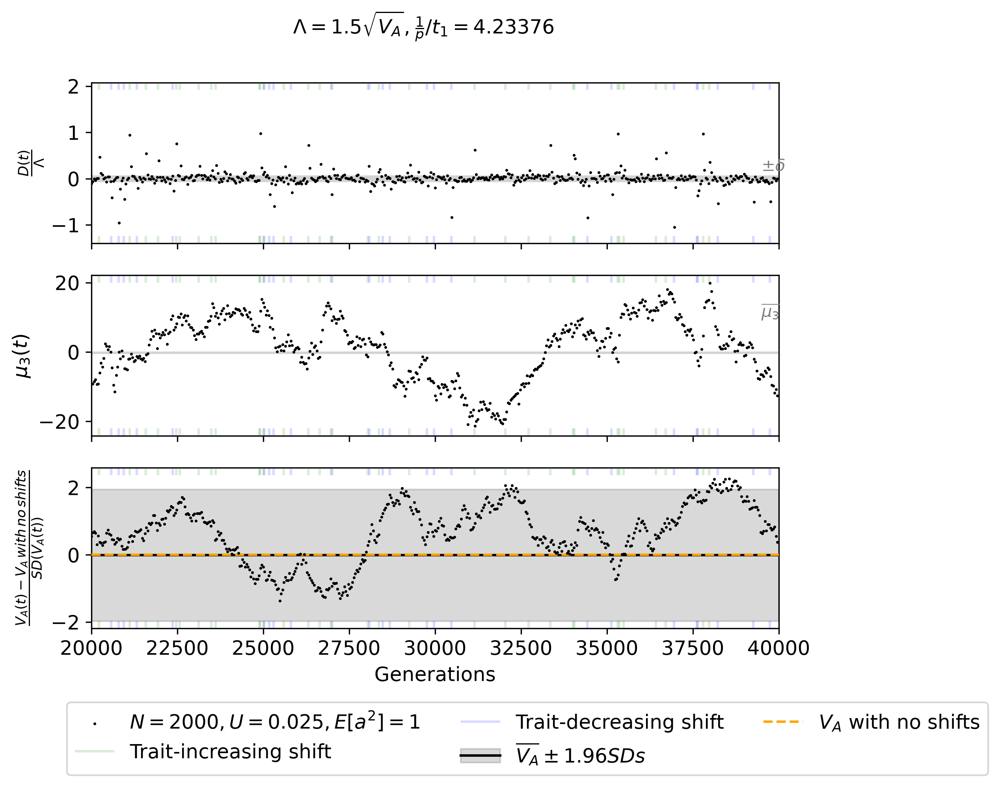

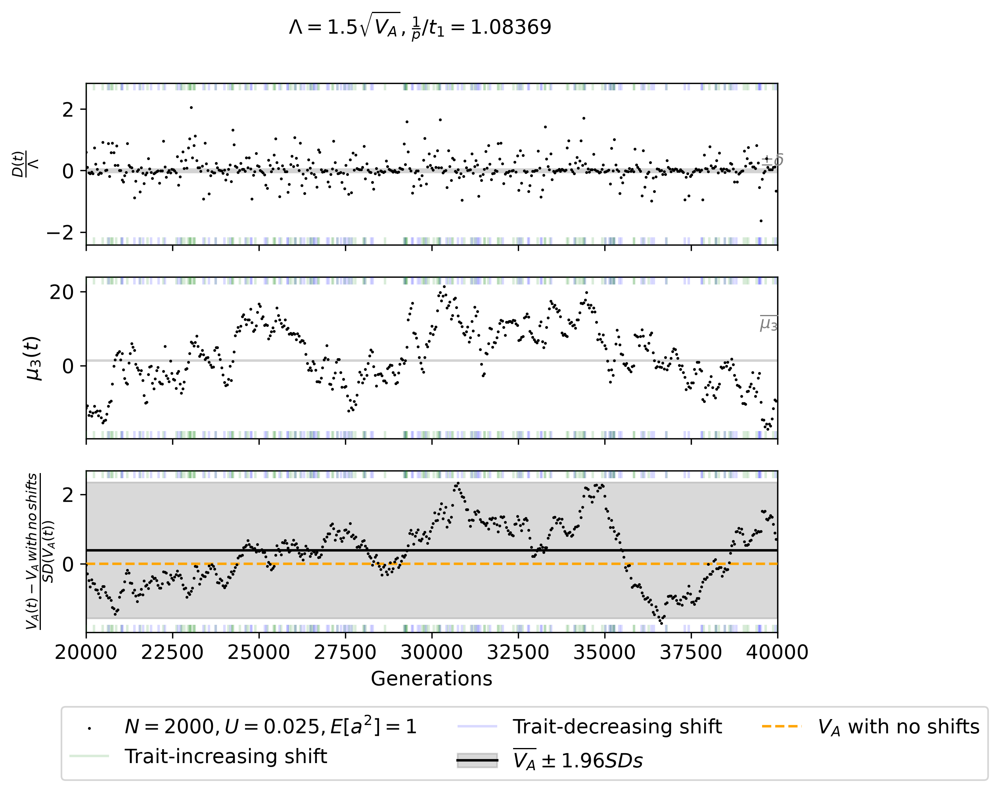

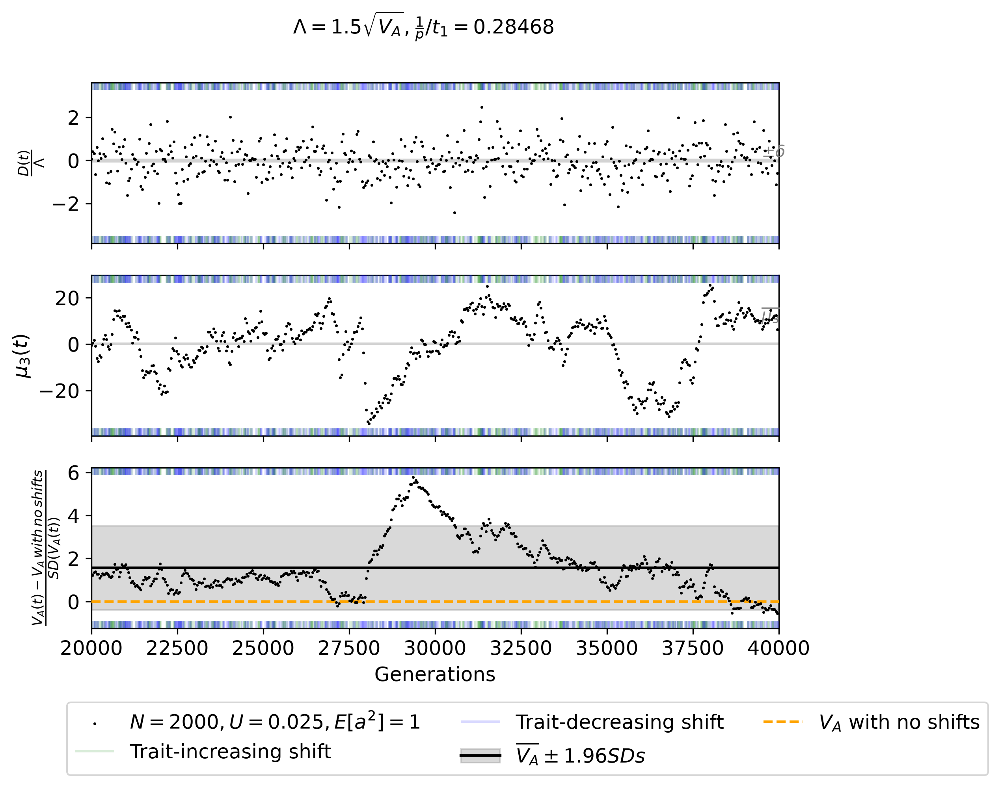

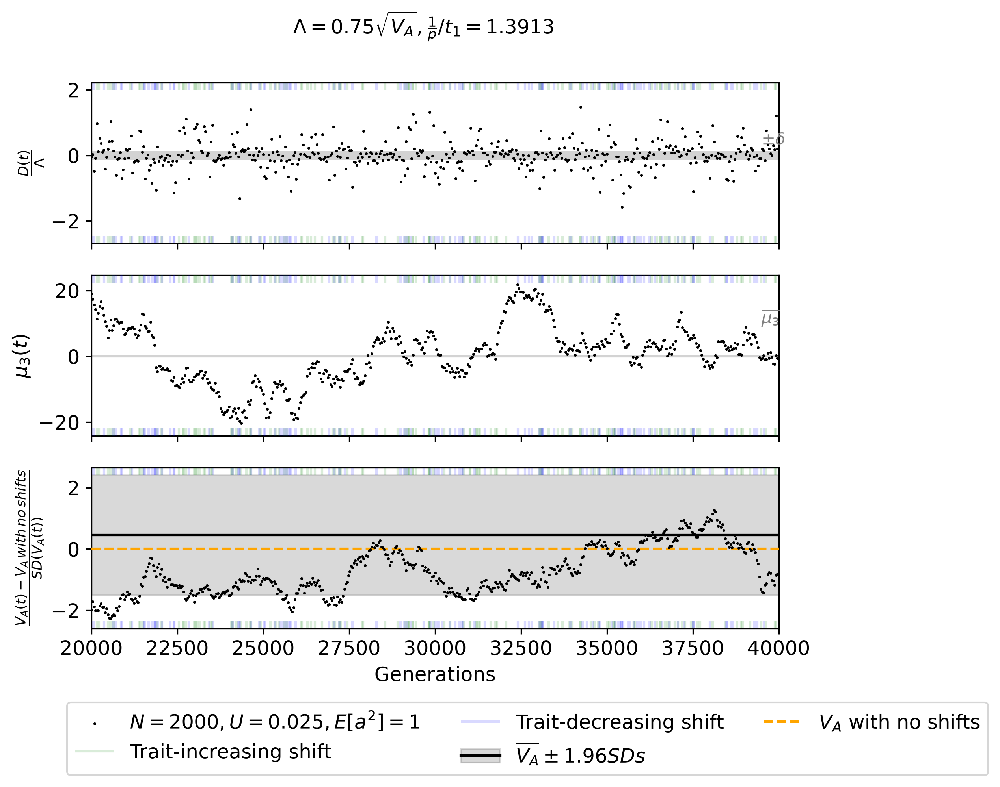

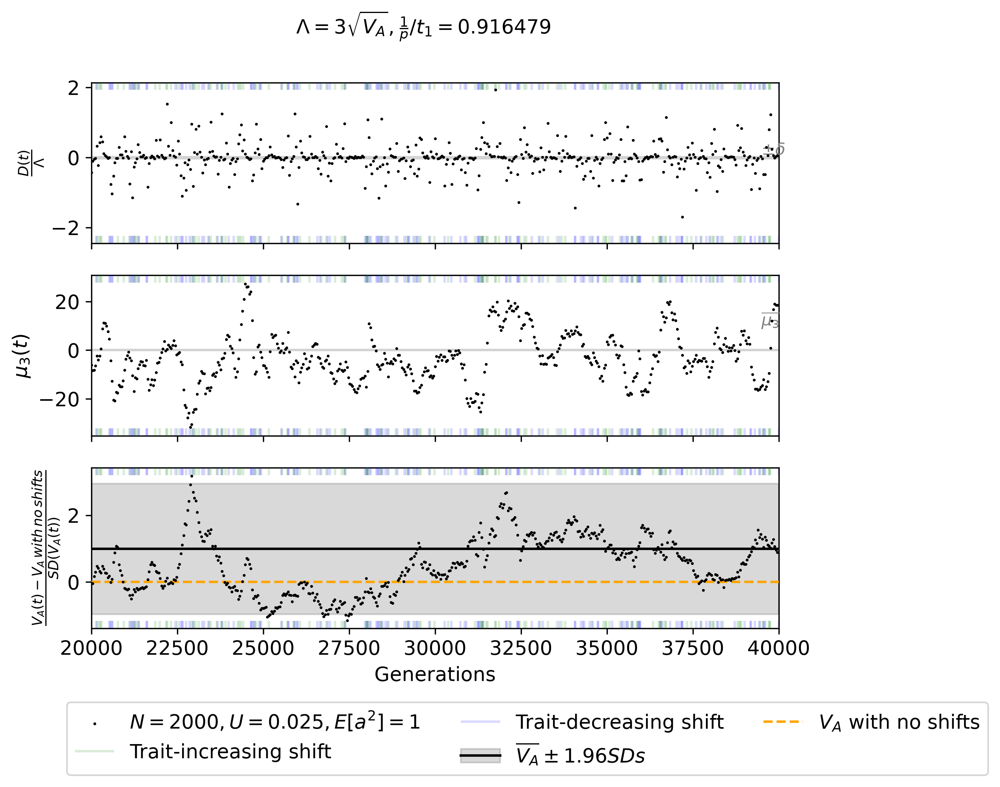

In [7]:
# 10N generations
from math import ceil
E2Ns = 1

shift_s0_partitioning = 32
rate_of_shifts_partitioning = 57

for E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [(E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift) for E2Ns in [1, ] for index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [[3, 1.5, 4, 0.003], [3, 1.5, 6, 0.012], [3, 1.5, 8, 0.048], [1, 0.75, 6, 0.012], [5, 3, 6, 0.012]]]:
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_2000_U_0_025_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_nE_100_empirical_average_V_A_1/fixation_probability' % round(E2Ns), 'rb') as f:
        dist_ess_over_time, var_ess_over_time, mu3_over_time = pickle.load(f)[2:5]
    
    fig = plt.figure(figsize=(7.5, 6), dpi=300)
    axs = fig.subplots(3, 1, sharex=True)
    
    start_plot_time = 10 * N
    end_plot_time = start_plot_time + 10 * N
    start_time = start_plot_time - round(5 / rate_of_shift)
    end_time = end_plot_time + round(5 / rate_of_shift)
    
    for ax,data_temp in zip(axs,[dist_ess_over_time,mu3_over_time,var_ess_over_time]):
        
        ### plotting the data
        number_of_generations = end_plot_time - start_plot_time
        max_points = 500
        skip = ceil(number_of_generations/max_points)
        
        plotting_data = data_temp[start_plot_time:end_plot_time:skip]
        plotting_time = list(range(start_plot_time, end_plot_time))[::skip]
        max_y = max(data_temp[start_plot_time:end_plot_time])
        min_y = min(data_temp[start_plot_time:end_plot_time])
        
        ### plotting analytics and extra stuff
        if ax == axs[0]: # this is the distance
            ax.scatter(plotting_time,[dist_ess / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])) for dist_ess in dist_ess_over_time[start_plot_time:end_plot_time:skip]], zorder=10,marker='.',color='k',s=2)
            # shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(start_time, end_time) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])]
            # for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
            #     ax.plot(range(abs(shift_time_directional), abs(next_shift_time_directional)), [dist_ess_over_time[abs(shift_time_directional)] / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])) * np.exp(-empirical_average_V_A[index_shift_s0][index_rate_of_shift] / (2 * N) * (t - abs(shift_time_directional))) for t in range(abs(shift_time_directional),abs(next_shift_time_directional))], color='r', linewidth=2, zorder=5)
            ax.fill_between(x=range(start_plot_time, end_plot_time), y1=-1 / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])), y2=1 / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])), interpolate=True, color='lightgray', label=r'$\pm\delta$', zorder=0)
            ax.text(x = start_plot_time + (end_plot_time-start_plot_time)*0.975, y = 3 / (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])), s = r'$\pm \delta$',color='gray')
            ax.set_ylabel(r'$\frac{D(t)}{\Lambda}$', fontsize=fontsize)
            
            max_y /= (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift]))
            min_y /= (shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift]))
            
        elif ax == axs[2]: # this is the second moment
            ax.scatter(plotting_time,np.divide(np.subtract(plotting_data, V_A(E2Ns=E2Ns)), empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift]), zorder=10,marker='.',color='k',s=2)
            simulations = ax.scatter([], [], marker='.',color='k',s=2)
            trait_increasing = ax.vlines(x=np.nan,ymin=np.nan,ymax=np.nan,color='g',alpha=0.15)
            trait_decreasing = ax.vlines(x=np.nan,ymin=np.nan,ymax=np.nan,color='b',alpha=0.15)
            # Lande, = ax.plot([], [], color='r')
            V_A_std = ax.fill_between(x=range(start_plot_time, end_plot_time), y1=(empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift] - 1.96, y2=(empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift] + 1.96, color='k', alpha=0.15, zorder=0)
            V_A_mean, = ax.plot([start_plot_time, end_plot_time], [(empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift]]*2, color='k', zorder=0)
            # analytic_V_A_root_finding = ax.hlines(y=(analytic_V_A[np.searchsorted(np.geomspace(0.5, 5, shift_s0_partitioning), shift_s0)][np.searchsorted(np.geomspace(0.0001875, 0.768, rate_of_shifts_partitioning), rate_of_shift)] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='orange', zorder=5)
            V_A_no_shifts = ax.hlines(y=0, xmin=start_plot_time, xmax=end_plot_time, colors='orange', zorder=5,ls='--')
            ax.set_ylabel(r'$\frac{V_A(t) - V_A\/with\/no\/shifts}{SD(V_A(t))}$', fontsize=fontsize)
            
            # min_y = min(min_y,(empirical_average_V_A[index_shift_s0][index_rate_of_shift] - 1.96 * empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift]))
            # max_y = max(max_y,(empirical_average_V_A[index_shift_s0][index_rate_of_shift] + 1.96 * empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift]))

            # min_y = min(min_y,V_A(E2Ns=E2Ns))
            # max_y = max(max_y,V_A(E2Ns=E2Ns))
            
            min_y = min((min_y - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift], (empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift] - 1.96)
            max_y = max((max_y - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift], (empirical_average_V_A_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD[index_shift_s0][index_rate_of_shift] + 1.96)

            min_y = min(min_y, 0)
            max_y = max(max_y, 0)
            
            ax.legend([simulations, trait_increasing, trait_decreasing, (V_A_std, V_A_mean), V_A_no_shifts], [r'$N=%d, U=%g, E[a^2]=%d$' % (N, U, round(E2Ns)), 'Trait-increasing shift', 'Trait-decreasing shift', r'$\overline{V_A} \pm 1.96SDs$', r'$V_A$ with no shifts'], loc='upper left', bbox_to_anchor=(-0.05, -0.4), fontsize=fontsize,ncols=3)
            
        elif ax == axs[1]: # this is the third moment
            ax.scatter(plotting_time,plotting_data, zorder=10,marker='.',color='k',s=2)
            ax.hlines(y=empirical_average_mu3_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='lightgray', zorder=0)
            ax.text(x = start_plot_time + (end_plot_time-start_plot_time)*0.975, y = 10, s = r'$\overline{\mu_{3}}$',color='gray')
            ax.set_ylabel(r'$\mu_3 (t)$', fontsize=fontsize)
            
            min_y = min(min_y, empirical_average_mu3_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift])
            max_y = max(max_y, empirical_average_mu3_from_empirical_average_V_A[index_shift_s0][index_rate_of_shift])
        
        ### things to do after plotting everything else
        min_y_limit = min_y-(max_y - min_y)/20
        max_y_limit = max_y+(max_y - min_y)/20
        
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])], ymin=min_y_limit, ymax=min_y, colors='g', alpha=0.15, zorder=5)
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])], ymin=max_y, ymax=max_y_limit, colors='g', alpha=0.15, zorder=5)
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])], ymin=min_y_limit, ymax=min_y, colors='b', alpha=0.15, zorder=5)
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift])], ymin=max_y, ymax=max_y_limit, colors='b', alpha=0.15, zorder=5)
        
        ax.set_ylim([min_y_limit,max_y_limit])
        
        ax.set_xlim([start_plot_time,end_plot_time])
        ax.tick_params(axis='y', labelsize=fontsize)
        
        
#     axs[0].scatter(range(start_time, end_time), dist_ess_over_time[start_time:end_time], zorder=10,marker='.',color='k')
#     shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(start_time, end_time) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
#     for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
#         t_1 = 2 * N / empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] * np.log(abs(dist_ess_over_time[abs(shift_time_directional)]))
#         axs[0].plot(range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))), [dist_ess_over_time[abs(shift_time_directional)] * np.exp(-empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] / (2 * N) * (t - abs(shift_time_directional))) for t in range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)))], color='r', linewidth=5, zorder=5)
#         if abs(next_shift_time_directional) > abs(shift_time_directional) + round(t_1):
#             axs[0].plot(range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)), [mu3_over_time[t] / (2 * var_ess_over_time[t]) for t in range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))], color='k', linewidth=5, zorder=5)
# #     axs[0].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(dist_ess_over_time[start_time:end_time]), ymax=max(dist_ess_over_time[start_time:end_time]), colors='g', zorder=5)
# #     axs[0].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(dist_ess_over_time[start_time:end_time]), ymax=max(dist_ess_over_time[start_time:end_time]), colors='b', zorder=5)
#     axs[0].fill_between(x=range(start_time, end_time), y1=-1, y2=1, interpolate=True, color='lightgray', label=r'$\pm\delta$', zorder=0)
#     axs[0].plot([], [], color='r', label='Lande')
#     axs[0].plot([], [], color='k', label='QS')
#     axs[0].set_ylabel(r'$D(t)$', fontsize=fontsize)
#     axs[0].tick_params(axis='y', labelsize=fontsize)
#     axs[0].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
    
# #     axs[2].scatter(range(start_time, end_time), var_ess_over_time[start_time:end_time], zorder=10,marker='.',color='k')
#     axs[2].fill_between(x=range(start_time, end_time), y1=empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], y2=empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] + 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], color='lightgray', alpha=0.5, label=r'$\overline{V_A}$', zorder=0)
#     axs[2].plot([start_time, end_time], [empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]]*2, color='lightgray', label=r'$\overline{V_A}$', zorder=0)
#     axs[2].hlines(y=empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='r', label=r'$\overline{V_A} w.r.t. (\Delta x_d^{nL})^2$', zorder=5)
#     axs[2].hlines(y=analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='k', label=r'$V_A(V_A\/under\/no\/shifts)$', zorder=5)
#     axs[2].hlines(y=V_A(E2Ns=16), xmin=start_time, xmax=end_time, colors='w', label=r'$V_A\/under\/no\/shifts$', zorder=5)
# #     axs[2].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(var_ess_over_time[start_time:end_time]), ymax=max(var_ess_over_time[start_time:end_time]), colors='g', zorder=5)
# #     axs[2].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(var_ess_over_time[start_time:end_time]), ymax=max(var_ess_over_time[start_time:end_time]), colors='b', zorder=5)
#     axs[2].set_ylabel(r'$V_A(t)$', fontsize=fontsize)
#     axs[2].tick_params(axis='y', labelsize=fontsize)
#     axs[2].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
    
# #     axs[1].scatter(range(start_time, end_time), mu3_over_time[start_time:end_time], zorder=10, marker='.',color='k')
#     axs[1].hlines(y=empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='lightgray', label=r'$\overline{\mu_3}$', zorder=0)
# #     axs[1].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(mu3_over_time[start_time:end_time]), ymax=max(mu3_over_time[start_time:end_time]), colors='g', label='Trait-increasing', zorder=5)
# #     axs[1].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(mu3_over_time[start_time:end_time]), ymax=max(mu3_over_time[start_time:end_time]), colors='b', label='Trait-decreasing', zorder=5)
#     axs[1].set_ylabel(r'$\mu_3(t)$', fontsize=fontsize)
#     axs[1].tick_params(axis='y', labelsize=fontsize)
#     axs[1].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
        
    plt.xlabel('Generations', fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    t_1 = 2 * N / empirical_average_V_A[index_shift_s0][index_rate_of_shift] * np.log(shift_s0 * np.sqrt(empirical_average_V_A[index_shift_s0][index_rate_of_shift]))
    plt.suptitle(r'$\Lambda=%g\sqrt{V_A}, \frac{1}{p} / t_1=%g$' % (shift_s0, 1.0 / rate_of_shift / t_1), fontsize=fontsize)
    plt.show()

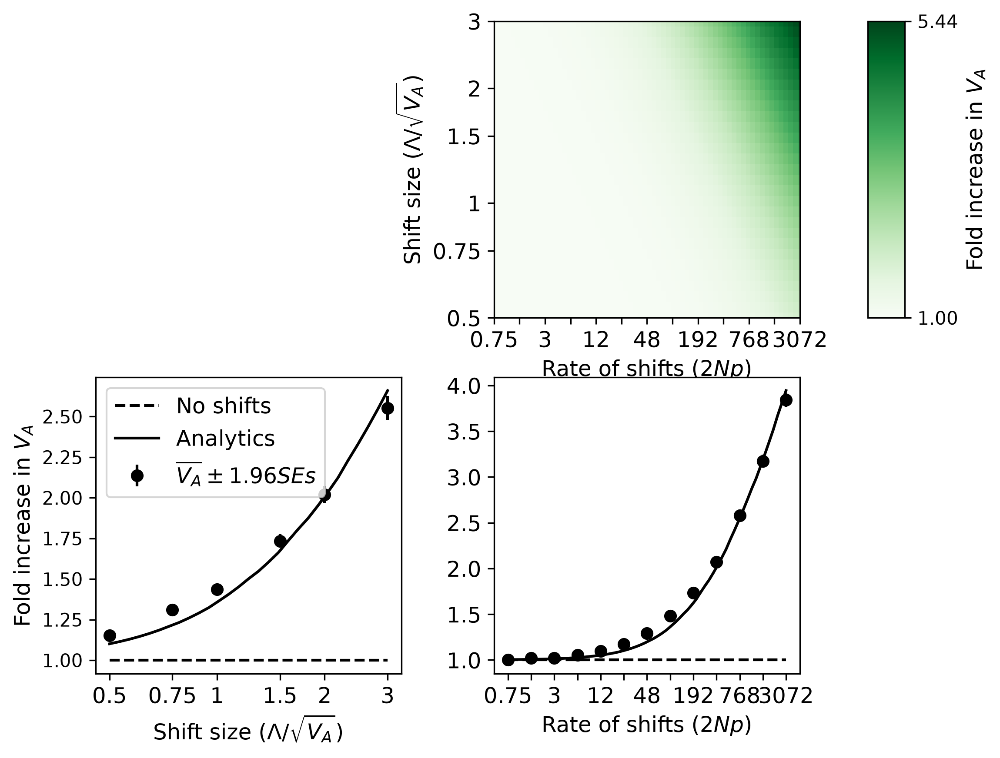

In [4]:
# the analytic V_A, in the non-Lande case
E2Ns = 16

fig = plt.figure(figsize=(8, 6.5), dpi=300)
gs = fig.add_gridspec(2, 5, width_ratios=[25, 3, 25, 1, 3], height_ratios=[1, 1])
# just for spacing
plt.subplot(gs[0, 1]).axis('off')
plt.subplot(gs[1, 1]).axis('off')
plt.subplot(gs[0, 3]).axis('off')
plt.subplot(gs[1, 3]).axis('off')
# not used
plt.subplot(gs[0, 0]).axis('off')
plt.subplot(gs[1, 4]).axis('off')
# make gs[0, 4] a colorbar
norm = colors.Normalize(vmin=analytic_V_A_nonLande.min() / V_A(E2Ns=E2Ns), vmax=analytic_V_A_nonLande.max() / V_A(E2Ns=E2Ns))
sm = plt.cm.ScalarMappable(cmap='Greens', norm=norm)
cbar = plt.colorbar(sm, cax=plt.subplot(gs[0, 4]), orientation='vertical')
cbar.set_label(r'Fold increase in $V_A$', fontsize=fontsize)
cbar.ax.set_yticks([analytic_V_A_nonLande.min() / V_A(E2Ns=E2Ns), analytic_V_A_nonLande.max() / V_A(E2Ns=E2Ns)])
cbar.ax.set_yticklabels(['%.2f' % (analytic_V_A_nonLande.min() / V_A(E2Ns=E2Ns)), '%.2f' % (analytic_V_A_nonLande.max() / V_A(E2Ns=E2Ns))])
cbar.ax.minorticks_off()
# make the other panels
ax = plt.subplot(gs[0, 2])

shift_s0_list = [0.5, 0.75, 1, 1.5, 2, 3]
rate_of_shifts_list = [0.0001875, 0.000375, 0.00075, 0.0015, 0.003, 0.006, 0.012, 0.024, 0.048, 0.096, 0.192, 0.384, 0.768]
shift_s0_partitioning = 29
rate_of_shifts_partitioning = 66

x = 2 * N * np.geomspace(rate_of_shifts_list[0] / (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_list[-1] * (rate_of_shifts_list[-1] / rate_of_shifts_list[0]) ** (0.5 / (rate_of_shifts_partitioning - 1)), rate_of_shifts_partitioning + 1)
y = np.geomspace(shift_s0_list[0] / (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_list[-1] * (shift_s0_list[-1] / shift_s0_list[0]) ** (0.5 / (shift_s0_partitioning - 1)), shift_s0_partitioning + 1)
X, Y = np.meshgrid(x, y)
ax.pcolormesh(X, Y, np.divide(analytic_V_A_nonLande, V_A(E2Ns=E2Ns)), cmap='Greens', norm=norm)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2 * N * rate_of_shifts_list[0], 2 * N * rate_of_shifts_list[-1])
ax.set_ylim(shift_s0_list[0], shift_s0_list[-1])
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_ylabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
assert len(rate_of_shifts_list) % 2 == 1
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
ax.set_yticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
ax.minorticks_off()

empirical_V_A_nonLande_mean = np.zeros((6, 13))
empirical_V_A_nonLande_se = np.zeros((6, 13))
for E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [(E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift) for E2Ns in [E2Ns, ] for index_shift_s0, shift_s0 in enumerate(shift_s0_list) for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)]:
    parallel_AA = 49
    var_ess_every_10N_generations = list()
    for i in range(1, 1 + parallel_AA):
        with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_%d_U_' % N + str(U).replace('.', '_') + '_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_nE_%d_empirical_average_V_A_%d/fixation_probability' % (round(E2Ns), 11, i), 'rb') as f:
            var_ess_every_10N_generations.extend(pickle.load(f)[3][10 * N::10 * N])
    empirical_V_A_nonLande_mean[index_shift_s0][index_rate_of_shift] = np.mean(var_ess_every_10N_generations)
    empirical_V_A_nonLande_se[index_shift_s0][index_rate_of_shift] = np.std(var_ess_every_10N_generations) / np.sqrt(np.size(var_ess_every_10N_generations))

ax = plt.subplot(gs[1, 0])
index_rate_of_shift, rate_of_shift = 44, 0.048
ax.plot(shift_s0_list, [1 for _ in shift_s0_list], 'k--', label='No shifts')
ax.plot(np.geomspace(shift_s0_list[0], shift_s0_list[-1], shift_s0_partitioning), np.divide(analytic_V_A_nonLande[:, index_rate_of_shift], V_A(E2Ns=E2Ns)), 'k-', label='Analytics')
ax.errorbar(shift_s0_list, np.divide(empirical_V_A_nonLande_mean[:, np.searchsorted(rate_of_shifts_list, rate_of_shift)], V_A(E2Ns=E2Ns)), yerr=1.96 * np.divide(empirical_V_A_nonLande_se[:, np.searchsorted(rate_of_shifts_list, rate_of_shift)], V_A(E2Ns=E2Ns)), fmt='o', color='k', label=r'$\overline{V_A} \pm 1.96SEs$')
ax.set_xscale('log')
ax.set_xlabel(r'Shift size ($\Lambda / \sqrt{V_A}$)', fontsize=fontsize)
ax.set_ylabel(r'Fold increase in $V_A$', fontsize=fontsize)
ax.set_xticks(ticks=shift_s0_list, labels=shift_s0_list, fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, 2Np=%g$' % (round(E2Ns), 2 * N * rate_of_shift), fontsize=fontsize)
ax.legend(bbox_to_anchor=(0., 1.), loc='upper left', fontsize=fontsize)
ax.minorticks_off()

ax = plt.subplot(gs[1, 2])
index_shift_s0, shift_s0 = 17, 1.5
ax.plot(2 * N * np.array(rate_of_shifts_list), [1 for _ in rate_of_shifts_list], 'k--', label='No shifts')
ax.plot(2 * N * np.geomspace(rate_of_shifts_list[0], rate_of_shifts_list[-1], rate_of_shifts_partitioning), np.divide(analytic_V_A_nonLande[index_shift_s0], V_A(E2Ns=E2Ns)), 'k-', label='Analytics')
ax.errorbar(2 * N * np.array(rate_of_shifts_list), np.divide(empirical_V_A_nonLande_mean[np.searchsorted(shift_s0_list, shift_s0)], V_A(E2Ns=E2Ns)), yerr=1.96 * np.divide(empirical_V_A_nonLande_se[np.searchsorted(shift_s0_list, shift_s0)], V_A(E2Ns=E2Ns)), fmt='o', color='k', label=r'$\overline{V_A} \pm 1.96SEs$')
ax.set_xscale('log')
ax.set_xlabel(r'Rate of shifts ($2Np$)', fontsize=fontsize)
ax.set_xticks(ticks=list(2 * N * np.array(rate_of_shifts_list)), labels=[2 * N * rate_of_shift if index_rate_of_shift % 2 == 0 and 2 * N * rate_of_shift != int(2 * N * rate_of_shift) else int(2 * N * rate_of_shift) if index_rate_of_shift % 2 == 0 else None for index_rate_of_shift, rate_of_shift in enumerate(rate_of_shifts_list)], fontsize=fontsize)
# ax.set_title('$E[a^2]=%d, \Lambda=%g\sqrt{V_A}$' % (round(E2Ns), shift_s0), fontsize=fontsize)
ax.minorticks_off()

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

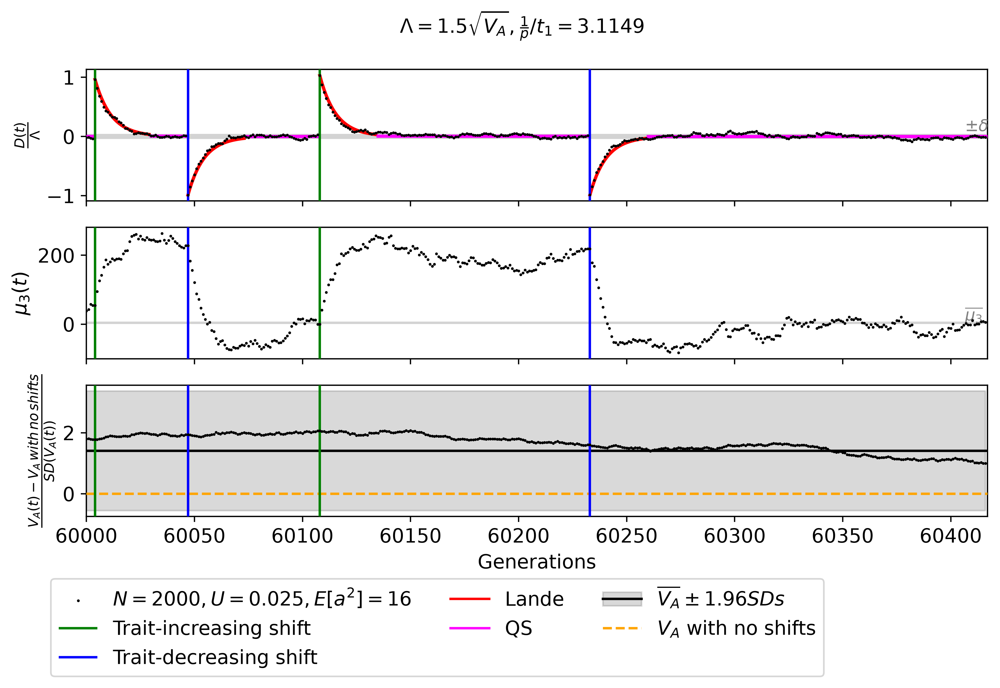

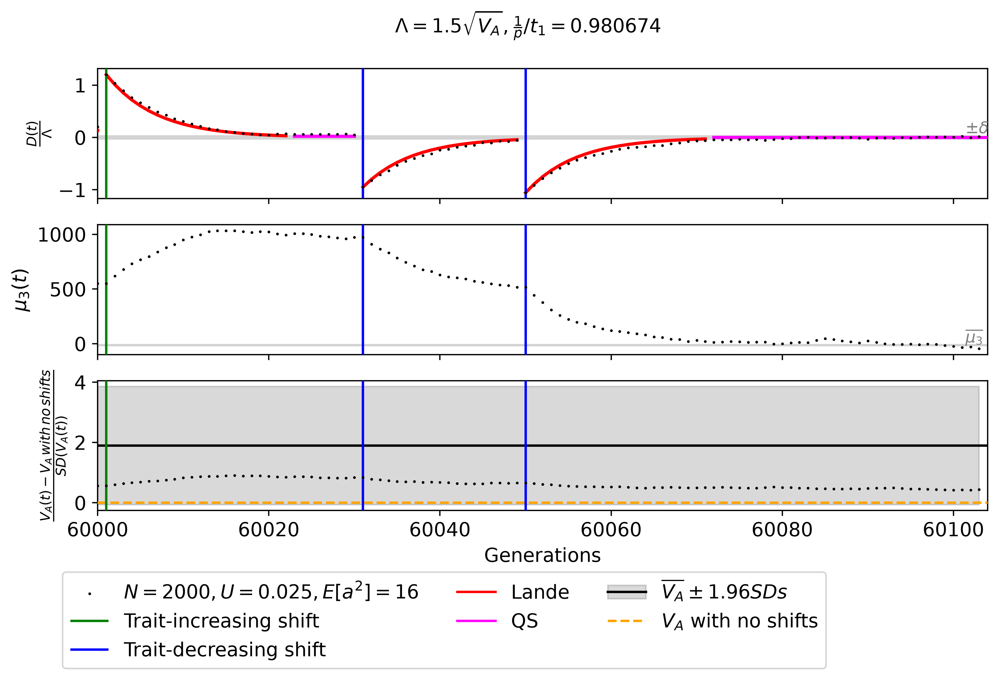

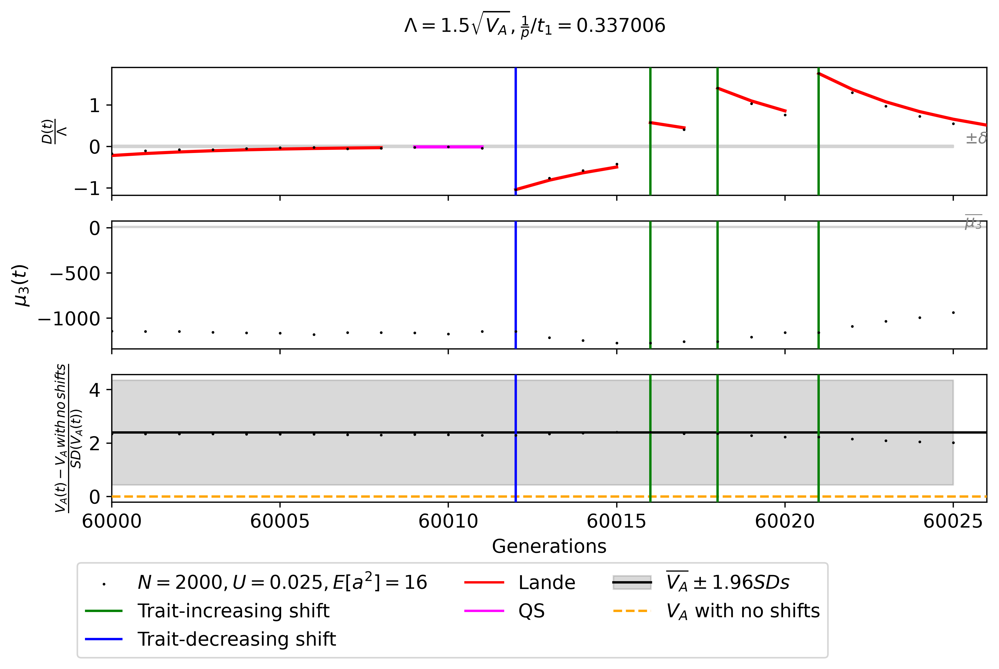

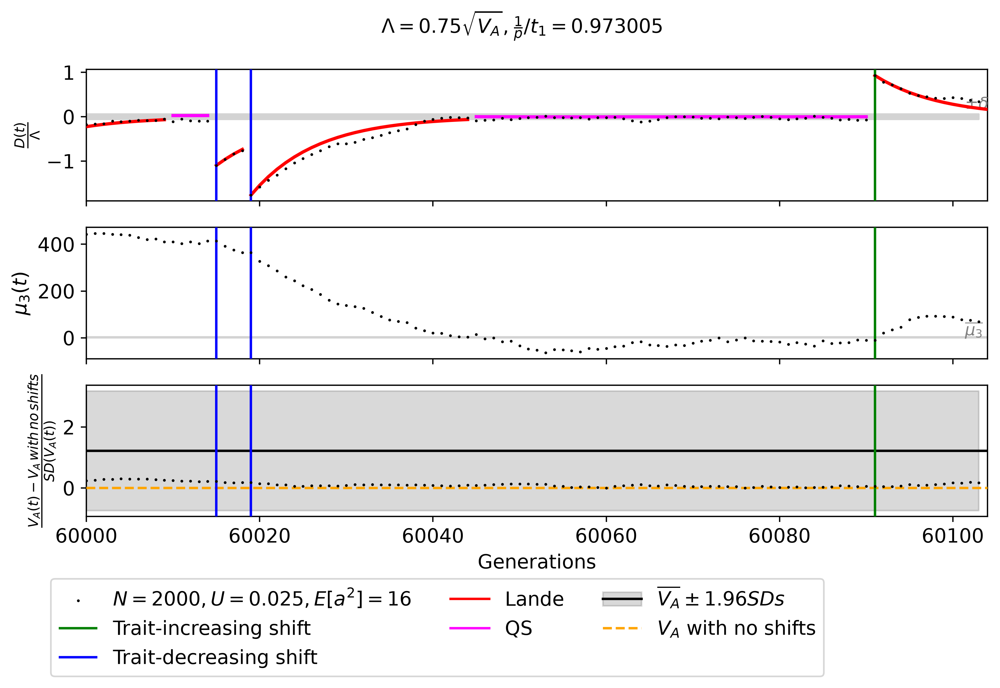

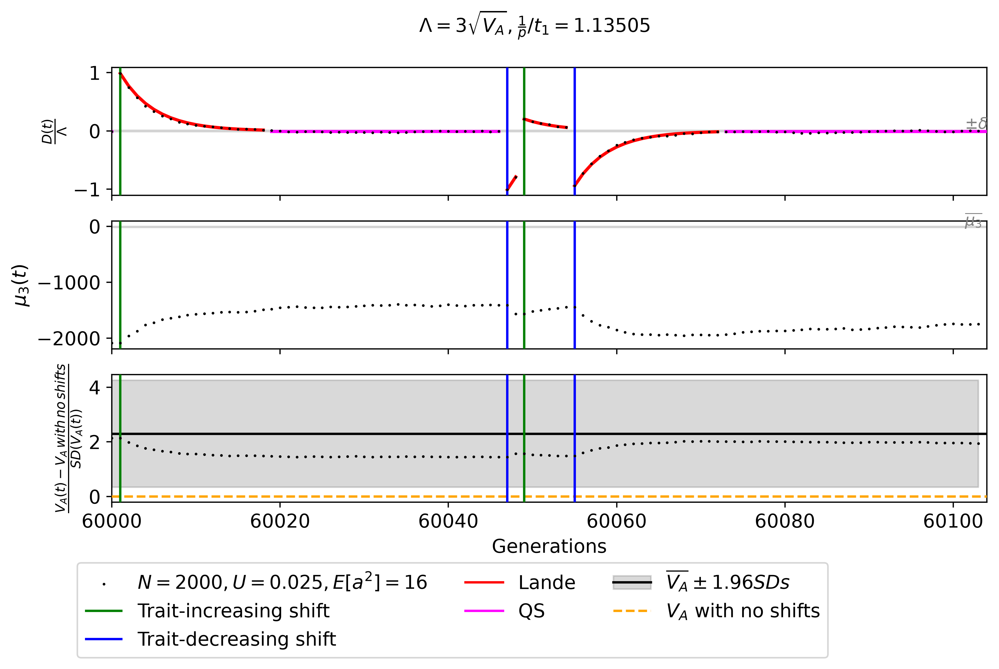

In [20]:
# D(t) in units of the shift size, \mu_3(t), and (V_A(t) - V_A under no shifts) / stdev(V_A(t)), in the non-Lande case
# ~5 shifts
from math import ceil
quasistatic_color = 'magenta'

for E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [(E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift) for E2Ns in [16, ] for index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [[3, 1.5, 6, 0.012], [3, 1.5, 8, 0.048], [3, 1.5, 10, 0.192], [1, 0.75, 8, 0.048], [5, 3, 8, 0.048]]]:
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_2000_U_0_025_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_nE_11_empirical_average_V_A_1/fixation_probability' % round(E2Ns), 'rb') as f:
        dist_ess_over_time, var_ess_over_time, mu3_over_time = pickle.load(f)[2:5]
    
    fig = plt.figure(figsize=(10, 5), dpi=400)
    axs = fig.subplots(3, 1, sharex=True)
    
    start_plot_time = 30 * N
    end_plot_time = 30 * N + round(5 / rate_of_shift)
    start_time = start_plot_time - round(5 / rate_of_shift)
    end_time = end_plot_time + round(5 / rate_of_shift)
    
    for ax,data_temp in zip(axs,[dist_ess_over_time,mu3_over_time,var_ess_over_time]):
        
        ### plotting the data
        number_of_generations = end_plot_time - start_plot_time
        max_points = 500
        skip = ceil(number_of_generations/max_points)
        
        plotting_data = data_temp[start_plot_time:end_plot_time:skip]
        plotting_time = list(range(start_plot_time, end_plot_time))[::skip]
        max_y = max(data_temp[start_plot_time:end_plot_time])
        min_y = min(data_temp[start_plot_time:end_plot_time])
        
        ### plotting analytics and extra stuff
        if ax == axs[0]: # this is the distance
            ax.scatter(plotting_time,[dist_ess / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])) for dist_ess in dist_ess_over_time[start_plot_time:end_plot_time:skip]], zorder=10,marker='.',color='k',s=2)
            shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(start_time, end_time) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
            for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
                t_1 = 2 * N / empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] * np.log(abs(dist_ess_over_time[abs(shift_time_directional)]))
                ax.plot(range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))), [dist_ess_over_time[abs(shift_time_directional)] / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])) * np.exp(-empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] / (2 * N) * (t - abs(shift_time_directional))) for t in range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)))], color='r', linewidth=2, zorder=5)
                if abs(next_shift_time_directional) > abs(shift_time_directional) + round(t_1):
                    ax.plot(range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)), [mu3_over_time[t] / (2 * var_ess_over_time[t]) / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])) for t in range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))], color=quasistatic_color, linewidth=2, zorder=5)
            ax.fill_between(x=range(start_plot_time, end_plot_time), y1=-1 / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])), y2=1 / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])), interpolate=True, color='lightgray', label=r'$\pm\delta$', zorder=0)
            ax.text(x = start_plot_time + (end_plot_time-start_plot_time)*0.975, y = 3 / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])), s = r'$\pm \delta$',color='gray')
            ax.set_ylabel(r'$\frac{D(t)}{\Lambda}$', fontsize=fontsize)
            
            max_y /= (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]))
            min_y /= (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]))
            
        elif ax == axs[2]: # this is the second moment
            ax.scatter(plotting_time,np.divide(np.subtract(plotting_data, V_A(E2Ns=E2Ns)), empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift]), zorder=10,marker='.',color='k',s=2)
            simulations = ax.scatter([], [], marker='.',color='k',s=2)
            trait_increasing = ax.vlines(x=np.nan,ymin=np.nan,ymax=np.nan,color='g')
            trait_decreasing = ax.vlines(x=np.nan,ymin=np.nan,ymax=np.nan,color='b')
            Lande, = ax.plot([], [], color='r')
            QS, = ax.plot([], [], color=quasistatic_color)
            V_A_std = ax.fill_between(x=range(start_plot_time, end_plot_time), y1=(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift] - 1.96, y2=(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift] + 1.96, color='k', alpha=0.15, zorder=0)
            V_A_mean, = ax.plot([start_plot_time, end_plot_time], [(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift]]*2, color='k', zorder=0)
            # V_A_for_analytics = ax.hlines(y=empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='k', zorder=5,ls='--')
            # analytic_V_A_root_finding = ax.hlines(y=analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='orange', zorder=5)
            V_A_no_shifts = ax.hlines(y=0, xmin=start_plot_time, xmax=end_plot_time, colors='orange', zorder=5,ls='--')
            ax.set_ylabel(r'$\frac{V_A(t) - V_A\/with\/no\/shifts}{SD(V_A(t))}$', fontsize=fontsize)
            
            min_y = min((min_y - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift],(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift] - 1.96)
            max_y = max((max_y - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift],(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift] + 1.96)
            
            min_y = min(min_y,0)
            max_y = max(max_y,0)
            
            ax.legend([simulations, trait_increasing, trait_decreasing, Lande, QS, (V_A_std, V_A_mean), V_A_no_shifts], [r'$N=%d, U=%g, E[a^2]=%d$' % (N, U, round(E2Ns)), 'Trait-increasing shift', 'Trait-decreasing shift', 'Lande', 'QS', r'$\overline{V_A} \pm 1.96SDs$', r'$V_A$ with no shifts'], loc='upper left', bbox_to_anchor=(-0.05, -0.4), fontsize=fontsize,ncols=3)
            
        elif ax == axs[1]: # this is the third moment
            ax.scatter(plotting_time,plotting_data, zorder=10,marker='.',color='k',s=2)
            ax.hlines(y=empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='lightgray', zorder=0)
            ax.text(x = start_plot_time + (end_plot_time-start_plot_time)*0.975, y = 10, s = r'$\overline{\mu_{3}}$',color='gray')
            ax.set_ylabel(r'$\mu_3 (t)$', fontsize=fontsize)
            
            min_y = min(min_y, empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])
            max_y = max(max_y, empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])
            
        ### things to do after plotting everything else
        min_y_limit = min_y-(max_y - min_y)/20
        max_y_limit = max_y+(max_y - min_y)/20
        
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min_y_limit, ymax=max_y_limit, colors='g', zorder=5)
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min_y_limit, ymax=max_y_limit, colors='b', zorder=5)
        
        ax.set_ylim([min_y_limit,max_y_limit])
        
        ax.set_xlim([start_plot_time,end_plot_time])
        ax.tick_params(axis='y', labelsize=fontsize)
        
        
#     axs[0].scatter(range(start_time, end_time), dist_ess_over_time[start_time:end_time], zorder=10,marker='.',color='k')
#     shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(start_time, end_time) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
#     for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
#         t_1 = 2 * N / empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] * np.log(abs(dist_ess_over_time[abs(shift_time_directional)]))
#         axs[0].plot(range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))), [dist_ess_over_time[abs(shift_time_directional)] * np.exp(-empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] / (2 * N) * (t - abs(shift_time_directional))) for t in range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)))], color='r', linewidth=5, zorder=5)
#         if abs(next_shift_time_directional) > abs(shift_time_directional) + round(t_1):
#             axs[0].plot(range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)), [mu3_over_time[t] / (2 * var_ess_over_time[t]) for t in range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))], color='k', linewidth=5, zorder=5)
# #     axs[0].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(dist_ess_over_time[start_time:end_time]), ymax=max(dist_ess_over_time[start_time:end_time]), colors='g', zorder=5)
# #     axs[0].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(dist_ess_over_time[start_time:end_time]), ymax=max(dist_ess_over_time[start_time:end_time]), colors='b', zorder=5)
#     axs[0].fill_between(x=range(start_time, end_time), y1=-1, y2=1, interpolate=True, color='lightgray', label=r'$\pm\delta$', zorder=0)
#     axs[0].plot([], [], color='r', label='Lande')
#     axs[0].plot([], [], color='k', label='QS')
#     axs[0].set_ylabel(r'$D(t)$', fontsize=fontsize)
#     axs[0].tick_params(axis='y', labelsize=fontsize)
#     axs[0].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
    
# #     axs[2].scatter(range(start_time, end_time), var_ess_over_time[start_time:end_time], zorder=10,marker='.',color='k')
#     axs[2].fill_between(x=range(start_time, end_time), y1=empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], y2=empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] + 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], color='lightgray', alpha=0.5, label=r'$\overline{V_A}$', zorder=0)
#     axs[2].plot([start_time, end_time], [empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]]*2, color='lightgray', label=r'$\overline{V_A}$', zorder=0)
#     axs[2].hlines(y=empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='r', label=r'$\overline{V_A} w.r.t. (\Delta x_d^{nL})^2$', zorder=5)
#     axs[2].hlines(y=analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='k', label=r'$V_A(V_A\/under\/no\/shifts)$', zorder=5)
#     axs[2].hlines(y=V_A(E2Ns=16), xmin=start_time, xmax=end_time, colors='w', label=r'$V_A\/under\/no\/shifts$', zorder=5)
# #     axs[2].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(var_ess_over_time[start_time:end_time]), ymax=max(var_ess_over_time[start_time:end_time]), colors='g', zorder=5)
# #     axs[2].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(var_ess_over_time[start_time:end_time]), ymax=max(var_ess_over_time[start_time:end_time]), colors='b', zorder=5)
#     axs[2].set_ylabel(r'$V_A(t)$', fontsize=fontsize)
#     axs[2].tick_params(axis='y', labelsize=fontsize)
#     axs[2].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
    
# #     axs[1].scatter(range(start_time, end_time), mu3_over_time[start_time:end_time], zorder=10, marker='.',color='k')
#     axs[1].hlines(y=empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='lightgray', label=r'$\overline{\mu_3}$', zorder=0)
# #     axs[1].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(mu3_over_time[start_time:end_time]), ymax=max(mu3_over_time[start_time:end_time]), colors='g', label='Trait-increasing', zorder=5)
# #     axs[1].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(mu3_over_time[start_time:end_time]), ymax=max(mu3_over_time[start_time:end_time]), colors='b', label='Trait-decreasing', zorder=5)
#     axs[1].set_ylabel(r'$\mu_3(t)$', fontsize=fontsize)
#     axs[1].tick_params(axis='y', labelsize=fontsize)
#     axs[1].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
        
    plt.xlabel('Generations', fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    t_1 = 2 * N / empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] * np.log(shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]))
    plt.suptitle(r'$\Lambda=%g\sqrt{V_A}, \frac{1}{p} / t_1=%g$' % (shift_s0, 1.0 / rate_of_shift / t_1), fontsize=fontsize)
    plt.show()

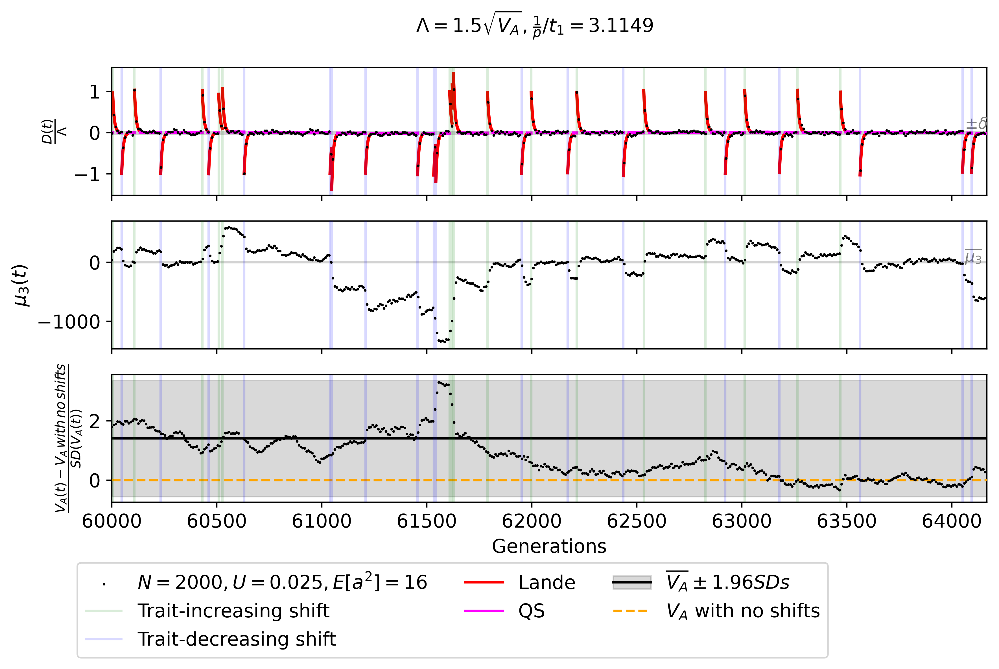

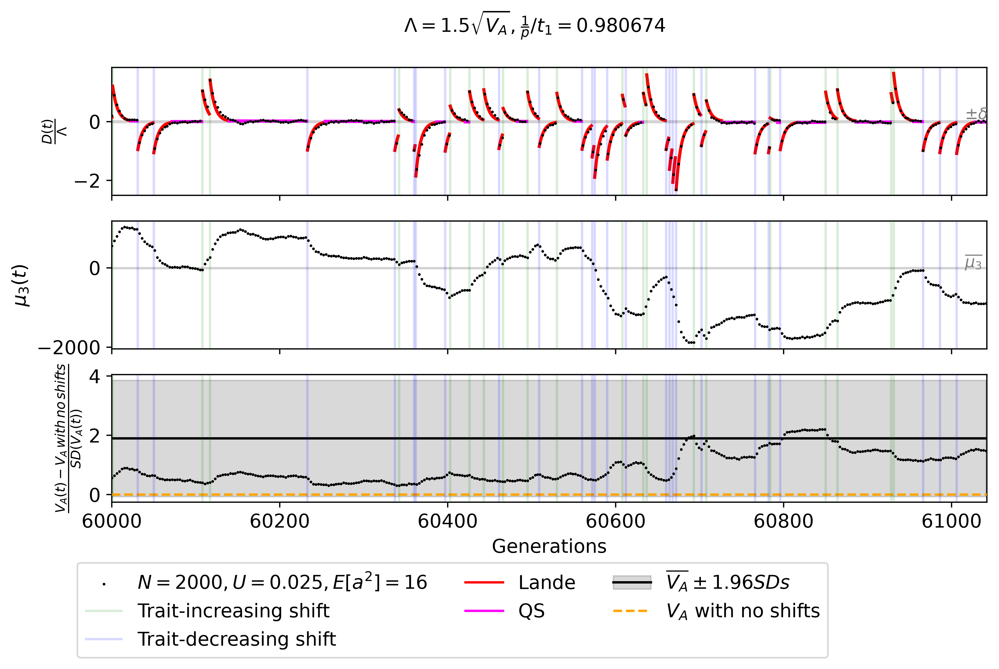

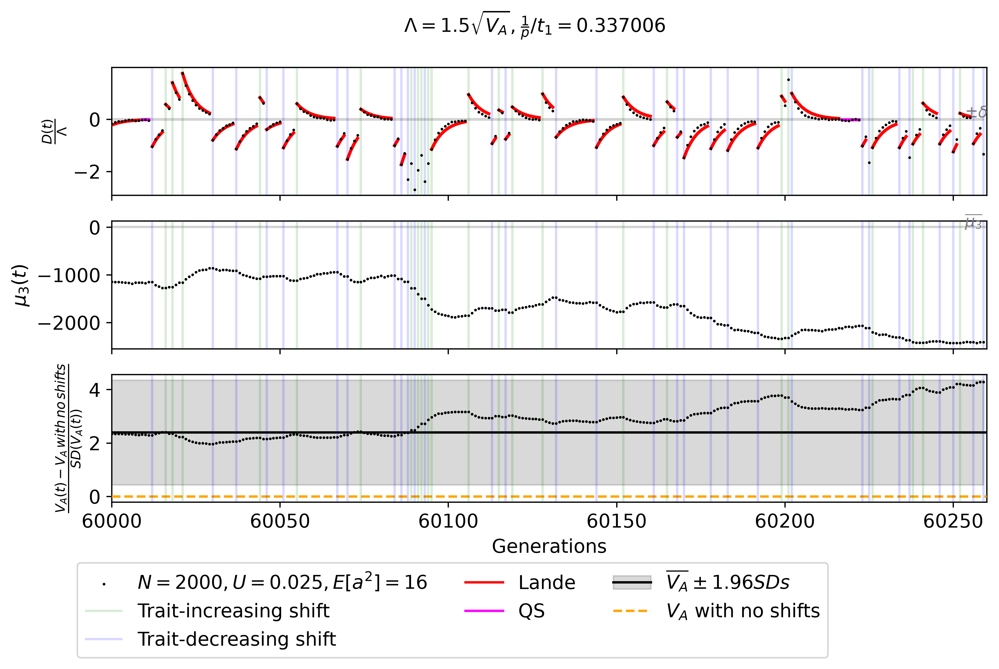

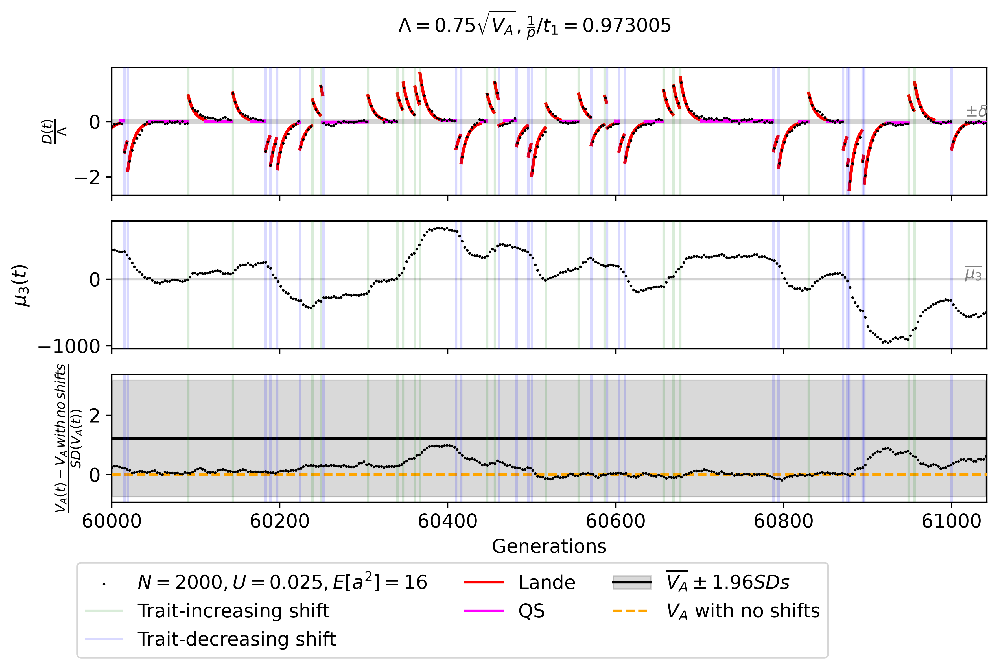

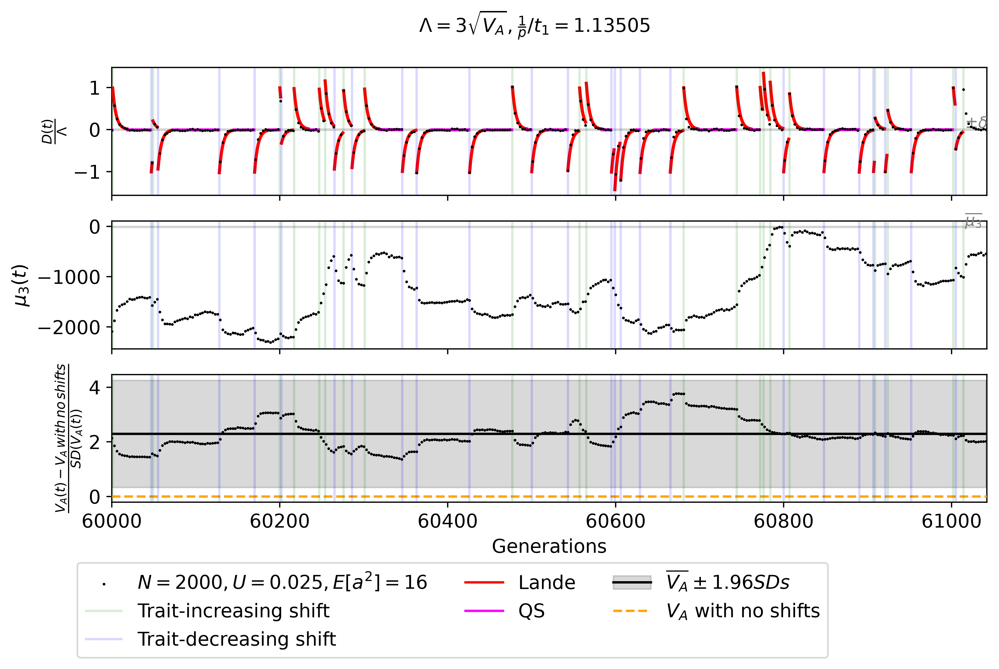

In [21]:
# ~50 shifts
from math import ceil
quasistatic_color = 'magenta'

for E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [(E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift) for E2Ns in [16, ] for index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [[3, 1.5, 6, 0.012], [3, 1.5, 8, 0.048], [3, 1.5, 10, 0.192], [1, 0.75, 8, 0.048], [5, 3, 8, 0.048]]]:
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_2000_U_0_025_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_nE_11_empirical_average_V_A_1/fixation_probability' % round(E2Ns), 'rb') as f:
        dist_ess_over_time, var_ess_over_time, mu3_over_time = pickle.load(f)[2:5]
    
    fig = plt.figure(figsize=(10, 5), dpi=400)
    axs = fig.subplots(3, 1, sharex=True)
    
    start_plot_time = 30 * N
    end_plot_time = 30 * N + round(50 / rate_of_shift)
    start_time = start_plot_time - round(5 / rate_of_shift)
    end_time = end_plot_time + round(5 / rate_of_shift)
    
    for ax,data_temp in zip(axs,[dist_ess_over_time,mu3_over_time,var_ess_over_time]):
        
        ### plotting the data
        number_of_generations = end_plot_time - start_plot_time
        max_points = 500
        skip = ceil(number_of_generations/max_points)
        
        plotting_data = data_temp[start_plot_time:end_plot_time:skip]
        plotting_time = list(range(start_plot_time, end_plot_time))[::skip]
        max_y = max(data_temp[start_plot_time:end_plot_time])
        min_y = min(data_temp[start_plot_time:end_plot_time])
        
        ### plotting analytics and extra stuff
        if ax == axs[0]: # this is the distance
            ax.scatter(plotting_time,[dist_ess / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])) for dist_ess in dist_ess_over_time[start_plot_time:end_plot_time:skip]], zorder=10,marker='.',color='k',s=2)
            shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(start_time, end_time) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
            for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
                t_1 = 2 * N / empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] * np.log(abs(dist_ess_over_time[abs(shift_time_directional)]))
                ax.plot(range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))), [dist_ess_over_time[abs(shift_time_directional)] / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])) * np.exp(-empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] / (2 * N) * (t - abs(shift_time_directional))) for t in range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)))], color='r', linewidth=2, zorder=5)
                if abs(next_shift_time_directional) > abs(shift_time_directional) + round(t_1):
                    ax.plot(range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)), [mu3_over_time[t] / (2 * var_ess_over_time[t]) / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])) for t in range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))], color=quasistatic_color, linewidth=2, zorder=5)
            ax.fill_between(x=range(start_plot_time, end_plot_time), y1=-1 / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])), y2=1 / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])), interpolate=True, color='lightgray', label=r'$\pm\delta$', zorder=0)
            ax.text(x = start_plot_time + (end_plot_time-start_plot_time)*0.975, y = 3 / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])), s = r'$\pm \delta$',color='gray')
            ax.set_ylabel(r'$\frac{D(t)}{\Lambda}$', fontsize=fontsize)
            
            max_y /= (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]))
            min_y /= (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]))
            
        elif ax == axs[2]: # this is the second moment
            ax.scatter(plotting_time,np.divide(np.subtract(plotting_data, V_A(E2Ns=E2Ns)), empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift]), zorder=10,marker='.',color='k',s=2)
            simulations = ax.scatter([], [], marker='.',color='k',s=2)
            trait_increasing = ax.vlines(x=np.nan,ymin=np.nan,ymax=np.nan,color='g',alpha=0.15)
            trait_decreasing = ax.vlines(x=np.nan,ymin=np.nan,ymax=np.nan,color='b',alpha=0.15)
            Lande, = ax.plot([], [], color='r')
            QS, = ax.plot([], [], color=quasistatic_color)
            V_A_std = ax.fill_between(x=range(start_plot_time, end_plot_time), y1=(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift] - 1.96, y2=(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift] + 1.96, color='k', alpha=0.15, zorder=0)
            V_A_mean, = ax.plot([start_plot_time, end_plot_time], [(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift]]*2, color='k', zorder=0)
            # V_A_for_analytics = ax.hlines(y=empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='k', zorder=5,ls='--')
            # analytic_V_A_root_finding = ax.hlines(y=analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='orange', zorder=5)
            V_A_no_shifts = ax.hlines(y=0, xmin=start_plot_time, xmax=end_plot_time, colors='orange', zorder=5,ls='--')
            ax.set_ylabel(r'$\frac{V_A(t) - V_A\/with\/no\/shifts}{SD(V_A(t))}$', fontsize=fontsize)
            
            min_y = min((min_y - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift],(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift] - 1.96)
            max_y = max((max_y - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift],(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift] + 1.96)
            
            min_y = min(min_y,0)
            max_y = max(max_y,0)
            
            ax.legend([simulations, trait_increasing, trait_decreasing, Lande, QS, (V_A_std, V_A_mean), V_A_no_shifts], [r'$N=%d, U=%g, E[a^2]=%d$' % (N, U, round(E2Ns)), 'Trait-increasing shift', 'Trait-decreasing shift', 'Lande', 'QS', r'$\overline{V_A} \pm 1.96SDs$', r'$V_A$ with no shifts'], loc='upper left', bbox_to_anchor=(-0.05, -0.4), fontsize=fontsize,ncols=3)
            
        elif ax == axs[1]: # this is the third moment
            ax.scatter(plotting_time,plotting_data, zorder=10,marker='.',color='k',s=2)
            ax.hlines(y=empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='lightgray', zorder=0)
            ax.text(x = start_plot_time + (end_plot_time-start_plot_time)*0.975, y = 10, s = r'$\overline{\mu_{3}}$',color='gray')
            ax.set_ylabel(r'$\mu_3 (t)$', fontsize=fontsize)
            
            min_y = min(min_y, empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])
            max_y = max(max_y, empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])
            
        ### things to do after plotting everything else
        min_y_limit = min_y-(max_y - min_y)/20
        max_y_limit = max_y+(max_y - min_y)/20
        
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min_y_limit, ymax=max_y_limit, colors='g', alpha=0.15, zorder=5)
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min_y_limit, ymax=max_y_limit, colors='b', alpha=0.15, zorder=5)
        
        ax.set_ylim([min_y_limit,max_y_limit])
        
        ax.set_xlim([start_plot_time,end_plot_time])
        ax.tick_params(axis='y', labelsize=fontsize)
        
        
#     axs[0].scatter(range(start_time, end_time), dist_ess_over_time[start_time:end_time], zorder=10,marker='.',color='k')
#     shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(start_time, end_time) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
#     for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
#         t_1 = 2 * N / empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] * np.log(abs(dist_ess_over_time[abs(shift_time_directional)]))
#         axs[0].plot(range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))), [dist_ess_over_time[abs(shift_time_directional)] * np.exp(-empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] / (2 * N) * (t - abs(shift_time_directional))) for t in range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)))], color='r', linewidth=5, zorder=5)
#         if abs(next_shift_time_directional) > abs(shift_time_directional) + round(t_1):
#             axs[0].plot(range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)), [mu3_over_time[t] / (2 * var_ess_over_time[t]) for t in range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))], color='k', linewidth=5, zorder=5)
# #     axs[0].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(dist_ess_over_time[start_time:end_time]), ymax=max(dist_ess_over_time[start_time:end_time]), colors='g', zorder=5)
# #     axs[0].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(dist_ess_over_time[start_time:end_time]), ymax=max(dist_ess_over_time[start_time:end_time]), colors='b', zorder=5)
#     axs[0].fill_between(x=range(start_time, end_time), y1=-1, y2=1, interpolate=True, color='lightgray', label=r'$\pm\delta$', zorder=0)
#     axs[0].plot([], [], color='r', label='Lande')
#     axs[0].plot([], [], color='k', label='QS')
#     axs[0].set_ylabel(r'$D(t)$', fontsize=fontsize)
#     axs[0].tick_params(axis='y', labelsize=fontsize)
#     axs[0].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
    
# #     axs[2].scatter(range(start_time, end_time), var_ess_over_time[start_time:end_time], zorder=10,marker='.',color='k')
#     axs[2].fill_between(x=range(start_time, end_time), y1=empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], y2=empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] + 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], color='lightgray', alpha=0.5, label=r'$\overline{V_A}$', zorder=0)
#     axs[2].plot([start_time, end_time], [empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]]*2, color='lightgray', label=r'$\overline{V_A}$', zorder=0)
#     axs[2].hlines(y=empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='r', label=r'$\overline{V_A} w.r.t. (\Delta x_d^{nL})^2$', zorder=5)
#     axs[2].hlines(y=analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='k', label=r'$V_A(V_A\/under\/no\/shifts)$', zorder=5)
#     axs[2].hlines(y=V_A(E2Ns=16), xmin=start_time, xmax=end_time, colors='w', label=r'$V_A\/under\/no\/shifts$', zorder=5)
# #     axs[2].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(var_ess_over_time[start_time:end_time]), ymax=max(var_ess_over_time[start_time:end_time]), colors='g', zorder=5)
# #     axs[2].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(var_ess_over_time[start_time:end_time]), ymax=max(var_ess_over_time[start_time:end_time]), colors='b', zorder=5)
#     axs[2].set_ylabel(r'$V_A(t)$', fontsize=fontsize)
#     axs[2].tick_params(axis='y', labelsize=fontsize)
#     axs[2].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
    
# #     axs[1].scatter(range(start_time, end_time), mu3_over_time[start_time:end_time], zorder=10, marker='.',color='k')
#     axs[1].hlines(y=empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='lightgray', label=r'$\overline{\mu_3}$', zorder=0)
# #     axs[1].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(mu3_over_time[start_time:end_time]), ymax=max(mu3_over_time[start_time:end_time]), colors='g', label='Trait-increasing', zorder=5)
# #     axs[1].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(mu3_over_time[start_time:end_time]), ymax=max(mu3_over_time[start_time:end_time]), colors='b', label='Trait-decreasing', zorder=5)
#     axs[1].set_ylabel(r'$\mu_3(t)$', fontsize=fontsize)
#     axs[1].tick_params(axis='y', labelsize=fontsize)
#     axs[1].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
        
    plt.xlabel('Generations', fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    t_1 = 2 * N / empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] * np.log(shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]))
    plt.suptitle(r'$\Lambda=%g\sqrt{V_A}, \frac{1}{p} / t_1=%g$' % (shift_s0, 1.0 / rate_of_shift / t_1), fontsize=fontsize)
    plt.show()

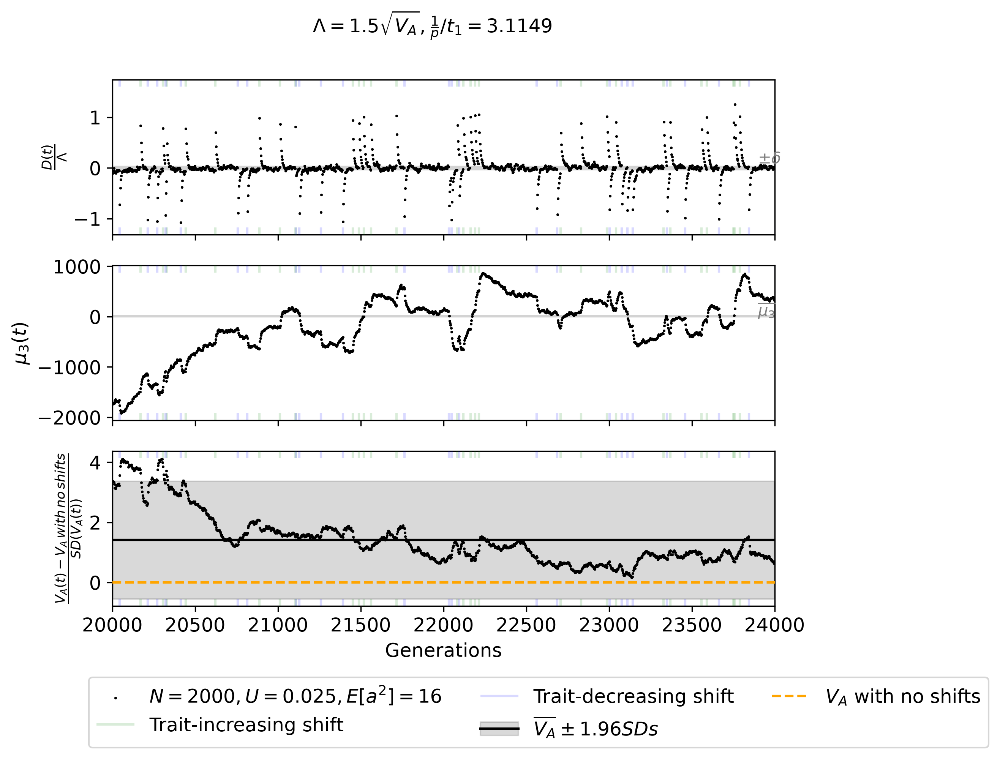

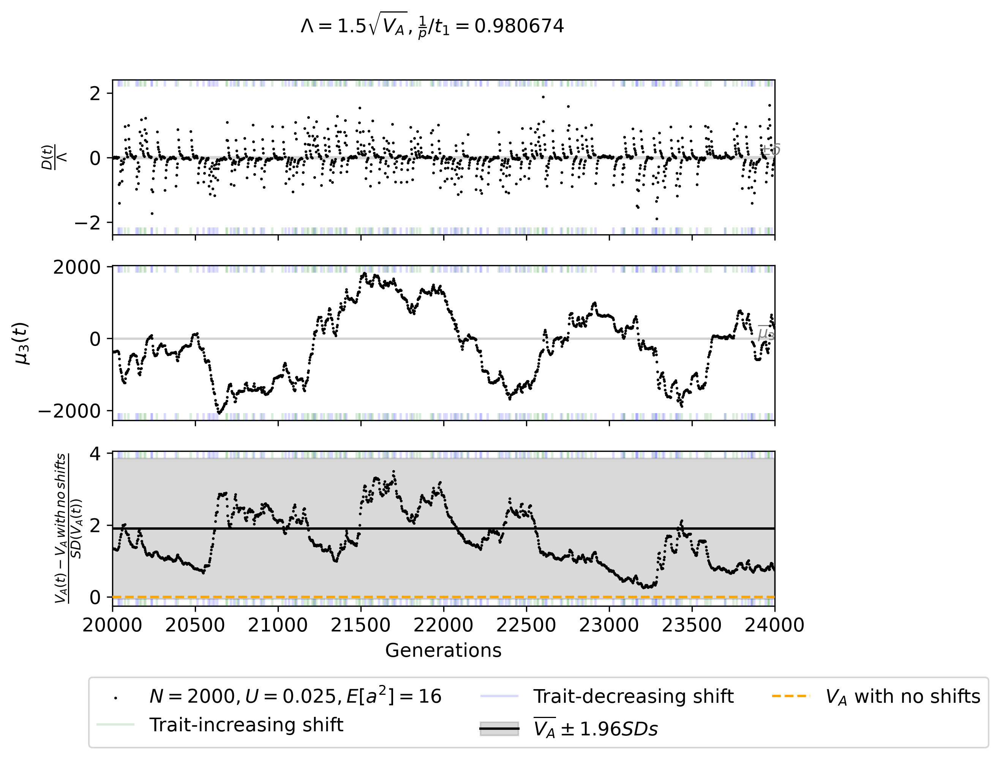

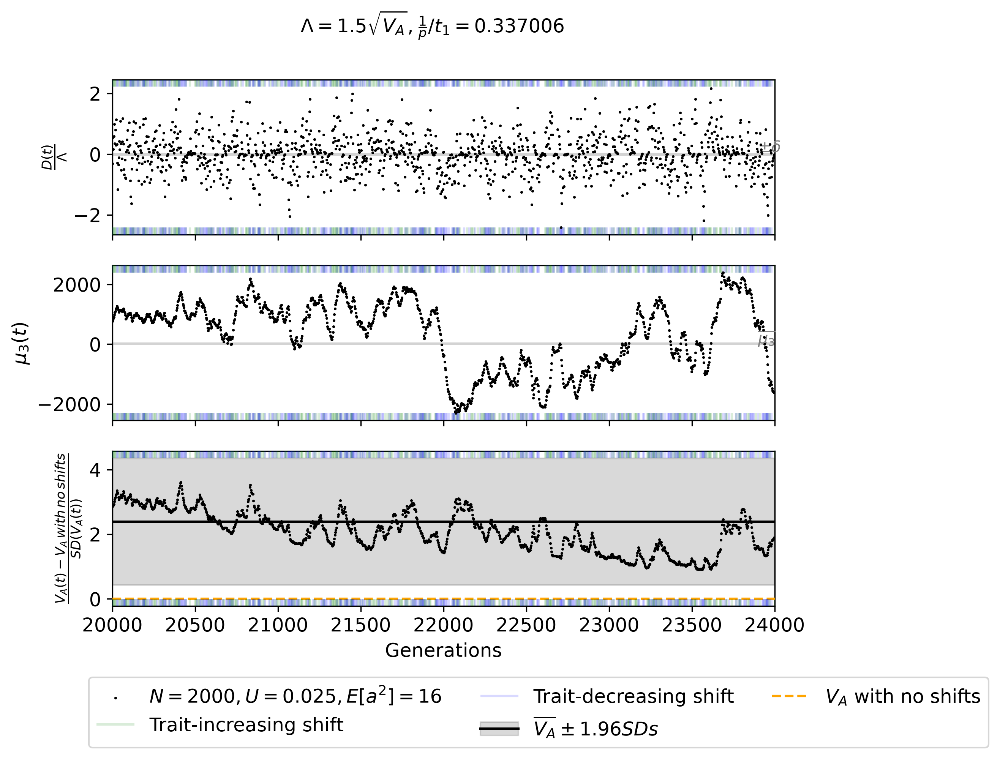

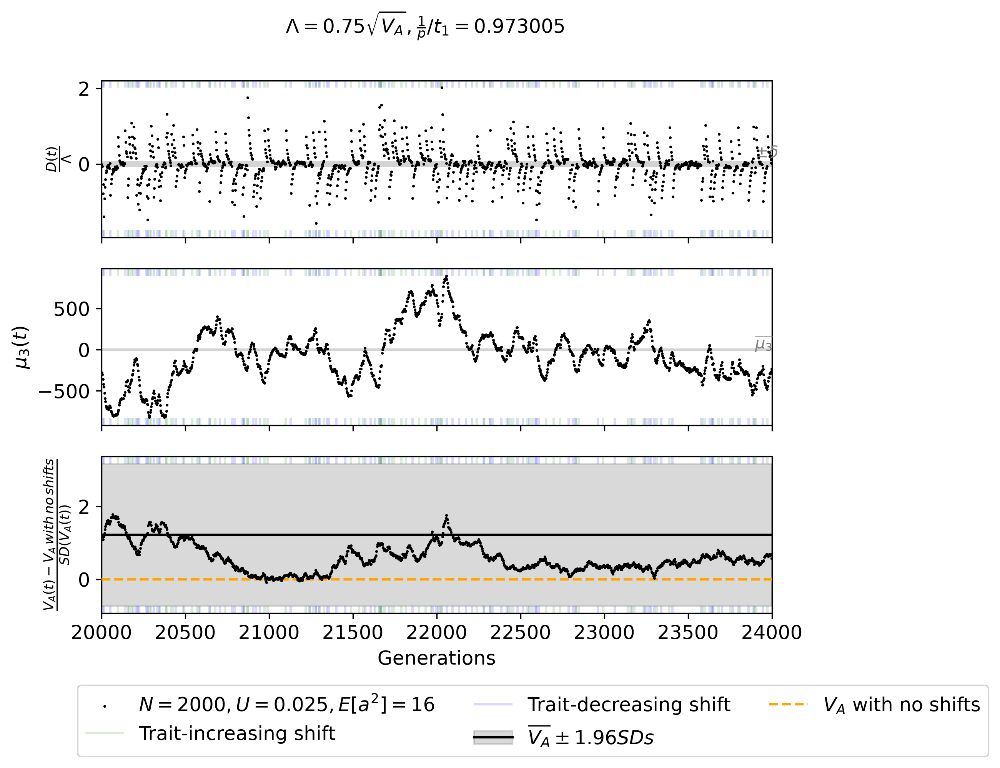

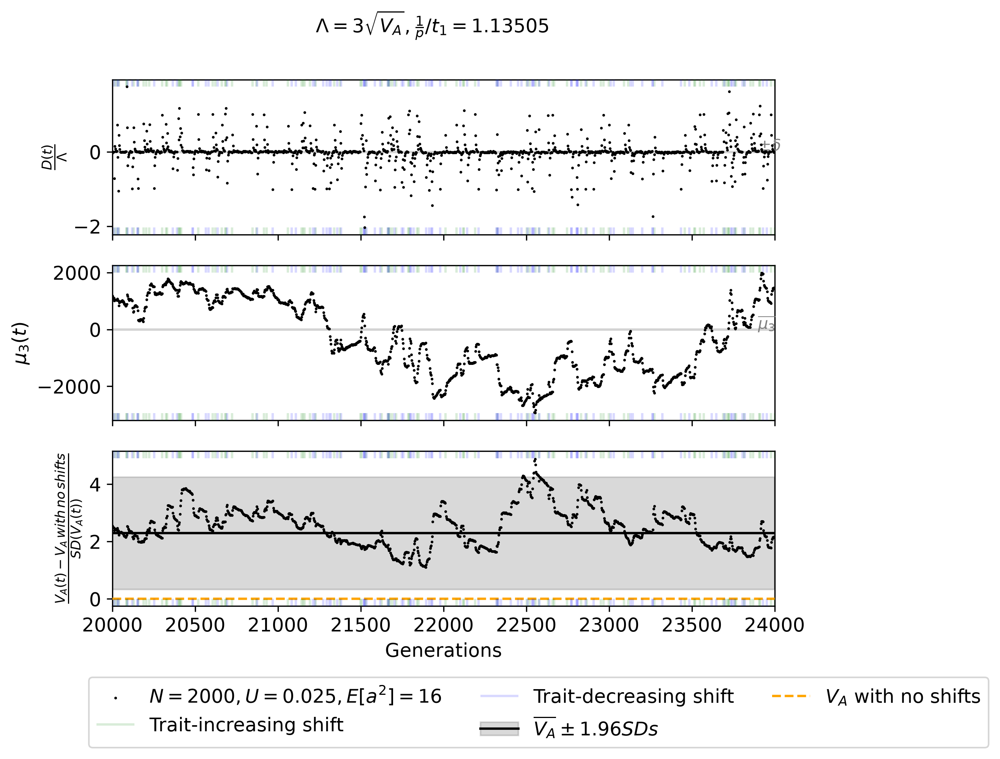

In [8]:
# 2N generations
from math import ceil
quasistatic_color = 'magenta'

for E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [(E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift) for E2Ns in [16, ] for index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [[3, 1.5, 6, 0.012], [3, 1.5, 8, 0.048], [3, 1.5, 10, 0.192], [1, 0.75, 8, 0.048], [5, 3, 8, 0.048]]]:
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_2000_U_0_025_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_nE_11_empirical_average_V_A_1/fixation_probability' % round(E2Ns), 'rb') as f:
        dist_ess_over_time, var_ess_over_time, mu3_over_time = pickle.load(f)[2:5]
    
    fig = plt.figure(figsize=(7.5, 6), dpi=300)
    axs = fig.subplots(3, 1, sharex=True)
    
    start_plot_time = 10 * N
    end_plot_time = start_plot_time + 2 * N
    start_time = start_plot_time - round(5 / rate_of_shift)
    end_time = end_plot_time + round(5 / rate_of_shift)
    
    for ax,data_temp in zip(axs,[dist_ess_over_time,mu3_over_time,var_ess_over_time]):
        
        ### plotting the data
        number_of_generations = end_plot_time - start_plot_time
        max_points = 1500
        skip = ceil(number_of_generations/max_points)
        
        plotting_data = data_temp[start_plot_time:end_plot_time:skip]
        plotting_time = list(range(start_plot_time, end_plot_time))[::skip]
        max_y = max(data_temp[start_plot_time:end_plot_time])
        min_y = min(data_temp[start_plot_time:end_plot_time])
        
        ### plotting analytics and extra stuff
        if ax == axs[0]: # this is the distance
            ax.scatter(plotting_time,[dist_ess / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])) for dist_ess in dist_ess_over_time[start_plot_time:end_plot_time:skip]], zorder=10,marker='.',color='k',s=2)
            # shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(start_time, end_time) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
            # for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
            #     t_1 = 2 * N / empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] * np.log(abs(dist_ess_over_time[abs(shift_time_directional)]))
            #     ax.plot(range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))), [dist_ess_over_time[abs(shift_time_directional)] / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])) * np.exp(-empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] / (2 * N) * (t - abs(shift_time_directional))) for t in range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)))], color='r', linewidth=2, zorder=5)
            #     if abs(next_shift_time_directional) > abs(shift_time_directional) + round(t_1):
            #         ax.plot(range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)), [mu3_over_time[t] / (2 * var_ess_over_time[t]) / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])) for t in range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))], color=quasistatic_color, linewidth=2, zorder=5)
            ax.fill_between(x=range(start_plot_time, end_plot_time), y1=-1 / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])), y2=1 / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])), interpolate=True, color='lightgray', label=r'$\pm\delta$', zorder=0)
            ax.text(x = start_plot_time + (end_plot_time-start_plot_time)*0.975, y = 3 / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])), s = r'$\pm \delta$',color='gray')
            ax.set_ylabel(r'$\frac{D(t)}{\Lambda}$', fontsize=fontsize)
            
            max_y /= (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]))
            min_y /= (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]))
            
        elif ax == axs[2]: # this is the second moment
            ax.scatter(plotting_time,np.divide(np.subtract(plotting_data, V_A(E2Ns=E2Ns)), empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift]), zorder=10,marker='.',color='k',s=2)
            simulations = ax.scatter([], [], marker='.',color='k',s=2)
            trait_increasing = ax.vlines(x=np.nan,ymin=np.nan,ymax=np.nan,color='g',alpha=0.15)
            trait_decreasing = ax.vlines(x=np.nan,ymin=np.nan,ymax=np.nan,color='b',alpha=0.15)
            # Lande, = ax.plot([], [], color='r')
            # QS, = ax.plot([], [], color=quasistatic_color)
            V_A_std = ax.fill_between(x=range(start_plot_time, end_plot_time), y1=(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift] - 1.96, y2=(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift] + 1.96, color='k', alpha=0.15, zorder=0)
            V_A_mean, = ax.plot([start_plot_time, end_plot_time], [(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift]]*2, color='k', zorder=0)
            # V_A_for_analytics = ax.hlines(y=(empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='k', zorder=5,ls='--')
            # analytic_V_A_root_finding = ax.hlines(y=(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='orange', zorder=5)
            V_A_no_shifts = ax.hlines(y=0, xmin=start_plot_time, xmax=end_plot_time, colors='orange', zorder=5,ls='--')
            ax.set_ylabel(r'$\frac{V_A(t) - V_A\/with\/no\/shifts}{SD(V_A(t))}$', fontsize=fontsize)
            
            # min_y = min(min_y,(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift]))
            # max_y = max(max_y,(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] + 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift]))
            
            # min_y = min(min_y,V_A(E2Ns=E2Ns))
            # max_y = max(max_y,V_A(E2Ns=E2Ns))

            min_y = min((min_y - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], (empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift] - 1.96)
            max_y = max((max_y - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], (empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift] + 1.96)

            min_y = min(min_y, 0)
            max_y = max(max_y, 0)
            
            ax.legend([simulations, trait_increasing, trait_decreasing, (V_A_std, V_A_mean), V_A_no_shifts], [r'$N=%d, U=%g, E[a^2]=%d$' % (N, U, round(E2Ns)), 'Trait-increasing shift', 'Trait-decreasing shift', r'$\overline{V_A} \pm 1.96SDs$', r'$V_A$ with no shifts'], loc='upper left', bbox_to_anchor=(-0.05, -0.4), fontsize=fontsize,ncols=3)
    
        elif ax == axs[1]: # this is the third moment
            ax.scatter(plotting_time,plotting_data, zorder=10,marker='.',color='k',s=2)
            ax.hlines(y=empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='lightgray', zorder=0)
            ax.text(x = start_plot_time + (end_plot_time-start_plot_time)*0.975, y = 10, s = r'$\overline{\mu_{3}}$',color='gray')
            ax.set_ylabel(r'$\mu_3 (t)$', fontsize=fontsize)
            
            min_y = min(min_y, empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])
            max_y = max(max_y, empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])
        
        ### things to do after plotting everything else
        min_y_limit = min_y-(max_y - min_y)/20
        max_y_limit = max_y+(max_y - min_y)/20
        
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min_y_limit, ymax=min_y, colors='g', alpha=0.15, zorder=5)
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=max_y, ymax=max_y_limit, colors='g', alpha=0.15, zorder=5)
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min_y_limit, ymax=min_y, colors='b', alpha=0.15, zorder=5)
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=max_y, ymax=max_y_limit, colors='b', alpha=0.15, zorder=5)
        
        ax.set_ylim([min_y_limit,max_y_limit])
        
        ax.set_xlim([start_plot_time,end_plot_time])
        ax.tick_params(axis='y', labelsize=fontsize)
        
        
#     axs[0].scatter(range(start_time, end_time), dist_ess_over_time[start_time:end_time], zorder=10,marker='.',color='k')
#     shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(start_time, end_time) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
#     for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
#         t_1 = 2 * N / empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] * np.log(abs(dist_ess_over_time[abs(shift_time_directional)]))
#         axs[0].plot(range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))), [dist_ess_over_time[abs(shift_time_directional)] * np.exp(-empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] / (2 * N) * (t - abs(shift_time_directional))) for t in range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)))], color='r', linewidth=5, zorder=5)
#         if abs(next_shift_time_directional) > abs(shift_time_directional) + round(t_1):
#             axs[0].plot(range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)), [mu3_over_time[t] / (2 * var_ess_over_time[t]) for t in range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))], color='k', linewidth=5, zorder=5)
# #     axs[0].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(dist_ess_over_time[start_time:end_time]), ymax=max(dist_ess_over_time[start_time:end_time]), colors='g', zorder=5)
# #     axs[0].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(dist_ess_over_time[start_time:end_time]), ymax=max(dist_ess_over_time[start_time:end_time]), colors='b', zorder=5)
#     axs[0].fill_between(x=range(start_time, end_time), y1=-1, y2=1, interpolate=True, color='lightgray', label=r'$\pm\delta$', zorder=0)
#     axs[0].plot([], [], color='r', label='Lande')
#     axs[0].plot([], [], color='k', label='QS')
#     axs[0].set_ylabel(r'$D(t)$', fontsize=fontsize)
#     axs[0].tick_params(axis='y', labelsize=fontsize)
#     axs[0].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
    
# #     axs[2].scatter(range(start_time, end_time), var_ess_over_time[start_time:end_time], zorder=10,marker='.',color='k')
#     axs[2].fill_between(x=range(start_time, end_time), y1=empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], y2=empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] + 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], color='lightgray', alpha=0.5, label=r'$\overline{V_A}$', zorder=0)
#     axs[2].plot([start_time, end_time], [empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]]*2, color='lightgray', label=r'$\overline{V_A}$', zorder=0)
#     axs[2].hlines(y=empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='r', label=r'$\overline{V_A} w.r.t. (\Delta x_d^{nL})^2$', zorder=5)
#     axs[2].hlines(y=analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='k', label=r'$V_A(V_A\/under\/no\/shifts)$', zorder=5)
#     axs[2].hlines(y=V_A(E2Ns=16), xmin=start_time, xmax=end_time, colors='w', label=r'$V_A\/under\/no\/shifts$', zorder=5)
# #     axs[2].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(var_ess_over_time[start_time:end_time]), ymax=max(var_ess_over_time[start_time:end_time]), colors='g', zorder=5)
# #     axs[2].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(var_ess_over_time[start_time:end_time]), ymax=max(var_ess_over_time[start_time:end_time]), colors='b', zorder=5)
#     axs[2].set_ylabel(r'$V_A(t)$', fontsize=fontsize)
#     axs[2].tick_params(axis='y', labelsize=fontsize)
#     axs[2].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
    
# #     axs[1].scatter(range(start_time, end_time), mu3_over_time[start_time:end_time], zorder=10, marker='.',color='k')
#     axs[1].hlines(y=empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='lightgray', label=r'$\overline{\mu_3}$', zorder=0)
# #     axs[1].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(mu3_over_time[start_time:end_time]), ymax=max(mu3_over_time[start_time:end_time]), colors='g', label='Trait-increasing', zorder=5)
# #     axs[1].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(mu3_over_time[start_time:end_time]), ymax=max(mu3_over_time[start_time:end_time]), colors='b', label='Trait-decreasing', zorder=5)
#     axs[1].set_ylabel(r'$\mu_3(t)$', fontsize=fontsize)
#     axs[1].tick_params(axis='y', labelsize=fontsize)
#     axs[1].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
        
    plt.xlabel('Generations', fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    t_1 = 2 * N / empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] * np.log(shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]))
    plt.suptitle(r'$\Lambda=%g\sqrt{V_A}, \frac{1}{p} / t_1=%g$' % (shift_s0, 1.0 / rate_of_shift / t_1), fontsize=fontsize)
    plt.show()

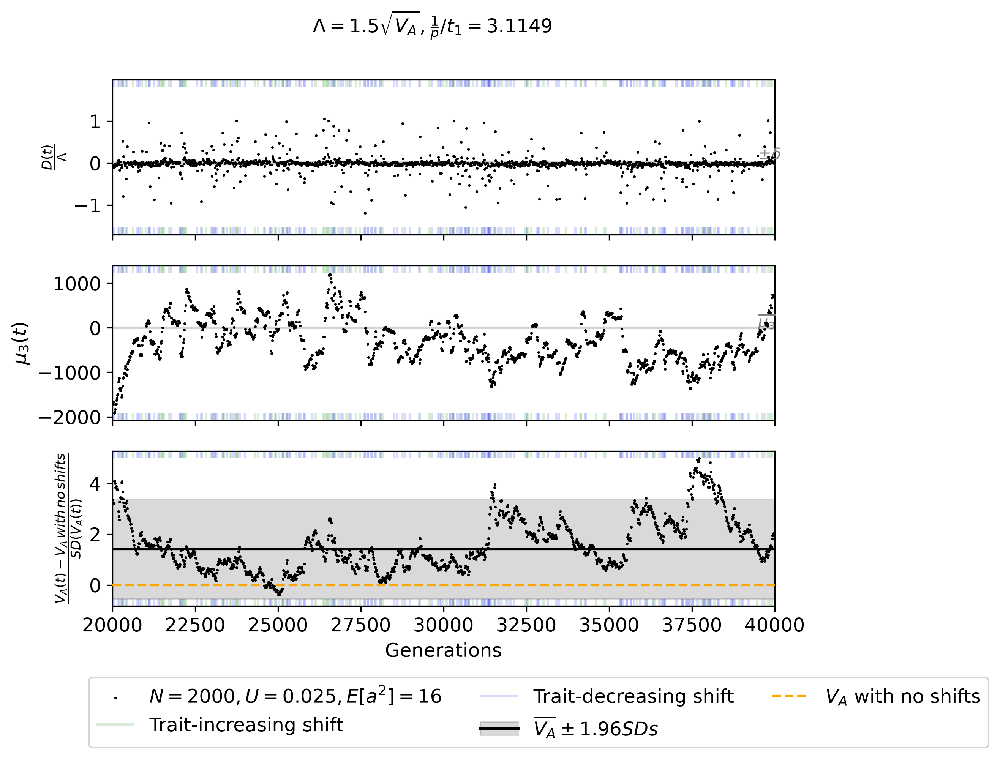

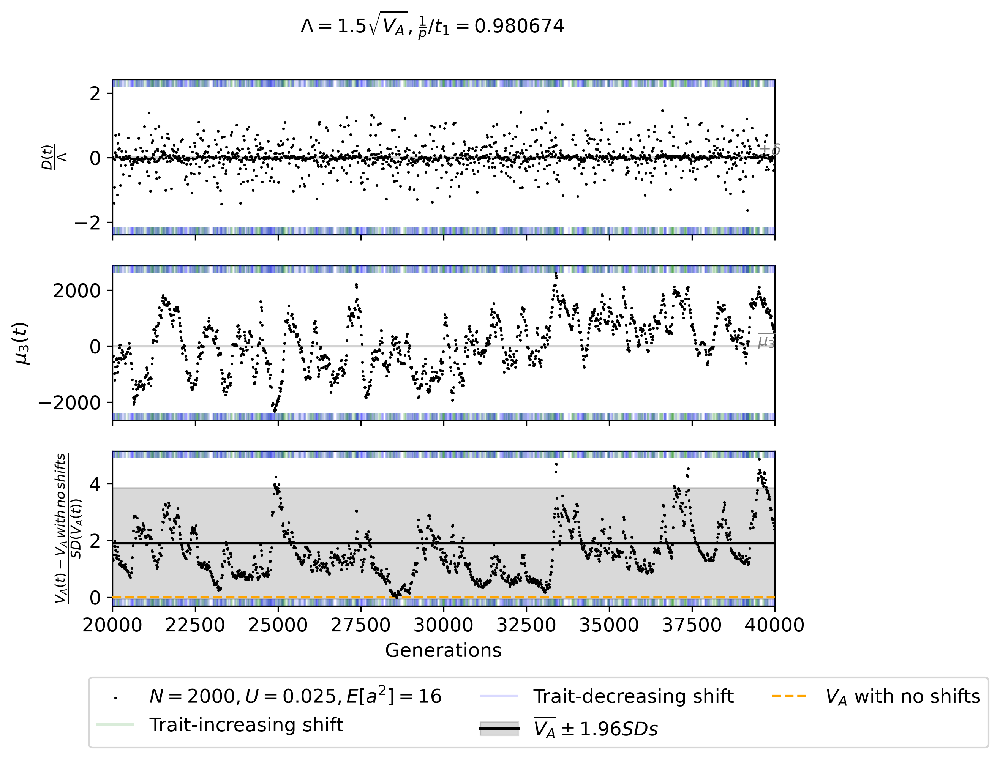

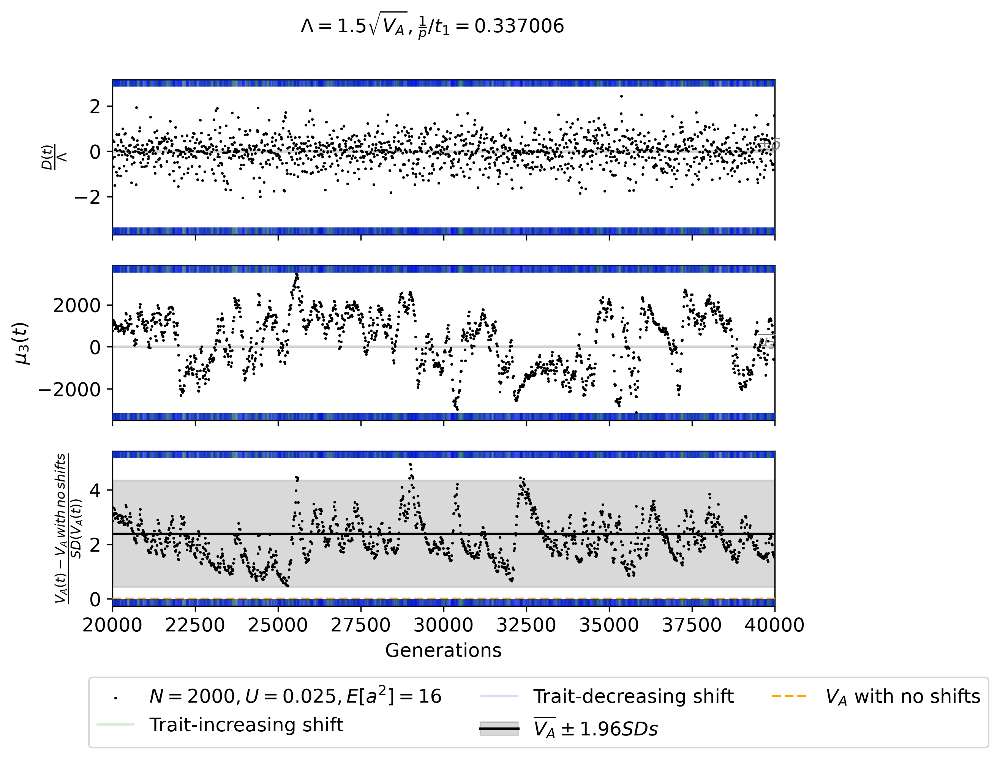

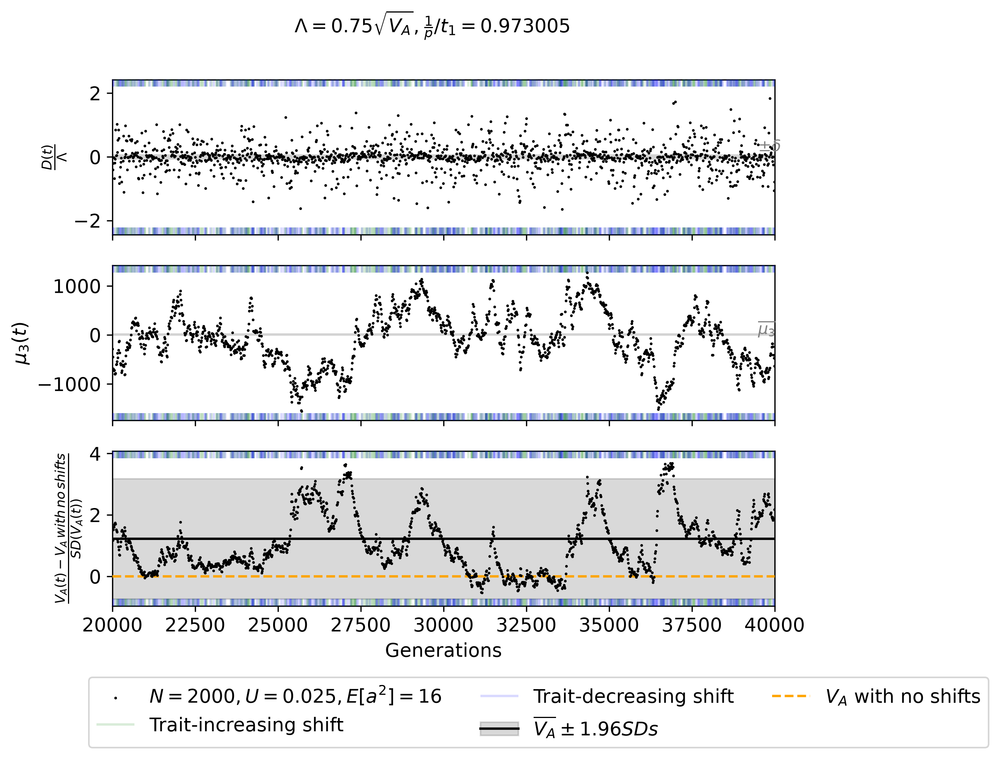

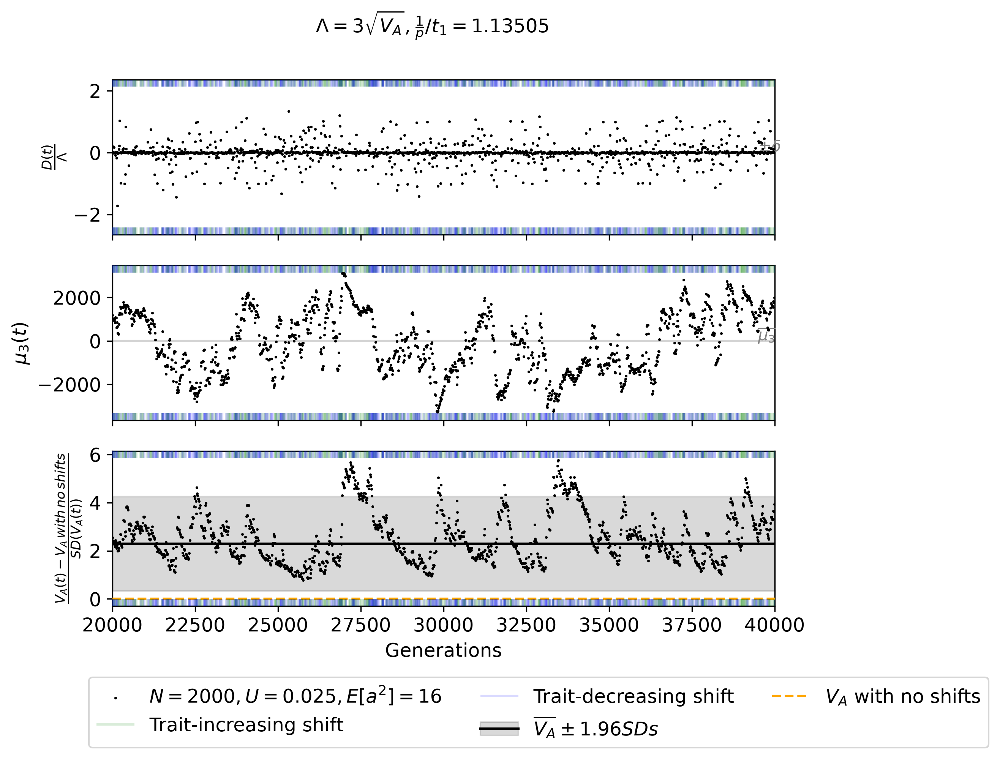

In [9]:
# 10N generations
from math import ceil
quasistatic_color = 'magenta'

for E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [(E2Ns, index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift) for E2Ns in [16, ] for index_shift_s0, shift_s0, index_rate_of_shift, rate_of_shift in [[3, 1.5, 6, 0.012], [3, 1.5, 8, 0.048], [3, 1.5, 10, 0.192], [1, 0.75, 8, 0.048], [5, 3, 8, 0.048]]]:
    with open('/insomnia001/depts/pas_lab/users/jc5473/my_AA_N_2000_U_0_025_shift_s0_' + str(shift_s0).replace('.', '_') + '_rate_of_shift_' + str(rate_of_shift).replace('.', '_') + '_E2Ns_%d_nE_11_empirical_average_V_A_1/fixation_probability' % round(E2Ns), 'rb') as f:
        dist_ess_over_time, var_ess_over_time, mu3_over_time = pickle.load(f)[2:5]
    
    fig = plt.figure(figsize=(7.5, 6), dpi=300)
    axs = fig.subplots(3, 1, sharex=True)
    
    start_plot_time = 10 * N
    end_plot_time = start_plot_time + 10 * N
    start_time = start_plot_time - round(5 / rate_of_shift)
    end_time = end_plot_time + round(5 / rate_of_shift)
    
    for ax,data_temp in zip(axs,[dist_ess_over_time,mu3_over_time,var_ess_over_time]):
        
        ### plotting the data
        number_of_generations = end_plot_time - start_plot_time
        max_points = 1500
        skip = ceil(number_of_generations/max_points)
        
        plotting_data = data_temp[start_plot_time:end_plot_time:skip]
        plotting_time = list(range(start_plot_time, end_plot_time))[::skip]
        max_y = max(data_temp[start_plot_time:end_plot_time])
        min_y = min(data_temp[start_plot_time:end_plot_time])
        
        ### plotting analytics and extra stuff
        if ax == axs[0]: # this is the distance
            ax.scatter(plotting_time,[dist_ess / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])) for dist_ess in dist_ess_over_time[start_plot_time:end_plot_time:skip]], zorder=10,marker='.',color='k',s=2)
            # shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(start_time, end_time) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
            # for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
            #     t_1 = 2 * N / empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] * np.log(abs(dist_ess_over_time[abs(shift_time_directional)]))
            #     ax.plot(range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))), [dist_ess_over_time[abs(shift_time_directional)] / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])) * np.exp(-empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] / (2 * N) * (t - abs(shift_time_directional))) for t in range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)))], color='r', linewidth=2, zorder=5)
            #     if abs(next_shift_time_directional) > abs(shift_time_directional) + round(t_1):
            #         ax.plot(range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)), [mu3_over_time[t] / (2 * var_ess_over_time[t]) / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])) for t in range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))], color=quasistatic_color, linewidth=2, zorder=5)
            ax.fill_between(x=range(start_plot_time, end_plot_time), y1=-1 / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])), y2=1 / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])), interpolate=True, color='lightgray', label=r'$\pm\delta$', zorder=0)
            ax.text(x = start_plot_time + (end_plot_time-start_plot_time)*0.975, y = 3 / (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])), s = r'$\pm \delta$',color='gray')
            ax.set_ylabel(r'$\frac{D(t)}{\Lambda}$', fontsize=fontsize)
            
            max_y /= (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]))
            min_y /= (shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]))
            
        elif ax == axs[2]: # this is the second moment
            ax.scatter(plotting_time,np.divide(np.subtract(plotting_data, V_A(E2Ns=E2Ns)), empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift]), zorder=10,marker='.',color='k',s=2)
            simulations = ax.scatter([], [], marker='.',color='k',s=2)
            trait_increasing = ax.vlines(x=np.nan,ymin=np.nan,ymax=np.nan,color='g',alpha=0.15)
            trait_decreasing = ax.vlines(x=np.nan,ymin=np.nan,ymax=np.nan,color='b',alpha=0.15)
            # Lande, = ax.plot([], [], color='r')
            # QS, = ax.plot([], [], color=quasistatic_color)
            V_A_std = ax.fill_between(x=range(start_plot_time, end_plot_time), y1=(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift] - 1.96, y2=(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift] + 1.96, color='k', alpha=0.15, zorder=0)
            V_A_mean, = ax.plot([start_plot_time, end_plot_time], [(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift]]*2, color='k', zorder=0)
            # V_A_for_analytics = ax.hlines(y=(empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='k', zorder=5,ls='--')
            # analytic_V_A_root_finding = ax.hlines(y=(analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='orange', zorder=5)
            V_A_no_shifts = ax.hlines(y=0, xmin=start_plot_time, xmax=end_plot_time, colors='orange', zorder=5,ls='--')
            ax.set_ylabel(r'$\frac{V_A(t) - V_A\/with\/no\/shifts}{SD(V_A(t))}$', fontsize=fontsize)
            
            # min_y = min(min_y,(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift]))
            # max_y = max(max_y,(empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] + 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift]))
            
            # min_y = min(min_y,V_A(E2Ns=E2Ns))
            # max_y = max(max_y,V_A(E2Ns=E2Ns))

            min_y = min((min_y - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], (empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift] - 1.96)
            max_y = max((max_y - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], (empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - V_A(E2Ns=E2Ns)) / empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift] + 1.96)

            min_y = min(min_y, 0)
            max_y = max(max_y, 0)
            
            ax.legend([simulations, trait_increasing, trait_decreasing, (V_A_std, V_A_mean), V_A_no_shifts], [r'$N=%d, U=%g, E[a^2]=%d$' % (N, U, round(E2Ns)), 'Trait-increasing shift', 'Trait-decreasing shift', r'$\overline{V_A} \pm 1.96SDs$', r'$V_A$ with no shifts'], loc='upper left', bbox_to_anchor=(-0.05, -0.4), fontsize=fontsize,ncols=3)
    
        elif ax == axs[1]: # this is the third moment
            ax.scatter(plotting_time,plotting_data, zorder=10,marker='.',color='k',s=2)
            ax.hlines(y=empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_plot_time, xmax=end_plot_time, colors='lightgray', zorder=0)
            ax.text(x = start_plot_time + (end_plot_time-start_plot_time)*0.975, y = 10, s = r'$\overline{\mu_{3}}$',color='gray')
            ax.set_ylabel(r'$\mu_3 (t)$', fontsize=fontsize)
            
            min_y = min(min_y, empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])
            max_y = max(max_y, empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])
        
        ### things to do after plotting everything else
        min_y_limit = min_y-(max_y - min_y)/20
        max_y_limit = max_y+(max_y - min_y)/20
        
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min_y_limit, ymax=min_y, colors='g', alpha=0.15, zorder=5)
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=max_y, ymax=max_y_limit, colors='g', alpha=0.15, zorder=5)
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min_y_limit, ymax=min_y, colors='b', alpha=0.15, zorder=5)
        ax.vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=max_y, ymax=max_y_limit, colors='b', alpha=0.15, zorder=5)
        
        ax.set_ylim([min_y_limit,max_y_limit])
        
        ax.set_xlim([start_plot_time,end_plot_time])
        ax.tick_params(axis='y', labelsize=fontsize)
        
        
#     axs[0].scatter(range(start_time, end_time), dist_ess_over_time[start_time:end_time], zorder=10,marker='.',color='k')
#     shift_times_directional = [tM * round((dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) / abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1])) for tM in range(start_time, end_time) if abs(dist_ess_over_time[tM] - dist_ess_over_time[tM - 1]) >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])]
#     for shift_time_directional, next_shift_time_directional in pairwise(shift_times_directional):
#         t_1 = 2 * N / empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] * np.log(abs(dist_ess_over_time[abs(shift_time_directional)]))
#         axs[0].plot(range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))), [dist_ess_over_time[abs(shift_time_directional)] * np.exp(-empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] / (2 * N) * (t - abs(shift_time_directional))) for t in range(abs(shift_time_directional), min(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)))], color='r', linewidth=5, zorder=5)
#         if abs(next_shift_time_directional) > abs(shift_time_directional) + round(t_1):
#             axs[0].plot(range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional)), [mu3_over_time[t] / (2 * var_ess_over_time[t]) for t in range(abs(shift_time_directional) + round(t_1), abs(next_shift_time_directional))], color='k', linewidth=5, zorder=5)
# #     axs[0].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(dist_ess_over_time[start_time:end_time]), ymax=max(dist_ess_over_time[start_time:end_time]), colors='g', zorder=5)
# #     axs[0].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(dist_ess_over_time[start_time:end_time]), ymax=max(dist_ess_over_time[start_time:end_time]), colors='b', zorder=5)
#     axs[0].fill_between(x=range(start_time, end_time), y1=-1, y2=1, interpolate=True, color='lightgray', label=r'$\pm\delta$', zorder=0)
#     axs[0].plot([], [], color='r', label='Lande')
#     axs[0].plot([], [], color='k', label='QS')
#     axs[0].set_ylabel(r'$D(t)$', fontsize=fontsize)
#     axs[0].tick_params(axis='y', labelsize=fontsize)
#     axs[0].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
    
# #     axs[2].scatter(range(start_time, end_time), var_ess_over_time[start_time:end_time], zorder=10,marker='.',color='k')
#     axs[2].fill_between(x=range(start_time, end_time), y1=empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] - 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], y2=empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] + 1.96 * empirical_V_A_from_empirical_average_V_A_SD_nonLande[index_shift_s0][index_rate_of_shift], color='lightgray', alpha=0.5, label=r'$\overline{V_A}$', zorder=0)
#     axs[2].plot([start_time, end_time], [empirical_average_V_A_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]]*2, color='lightgray', label=r'$\overline{V_A}$', zorder=0)
#     axs[2].hlines(y=empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='r', label=r'$\overline{V_A} w.r.t. (\Delta x_d^{nL})^2$', zorder=5)
#     axs[2].hlines(y=analytic_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='k', label=r'$V_A(V_A\/under\/no\/shifts)$', zorder=5)
#     axs[2].hlines(y=V_A(E2Ns=16), xmin=start_time, xmax=end_time, colors='w', label=r'$V_A\/under\/no\/shifts$', zorder=5)
# #     axs[2].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(var_ess_over_time[start_time:end_time]), ymax=max(var_ess_over_time[start_time:end_time]), colors='g', zorder=5)
# #     axs[2].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(var_ess_over_time[start_time:end_time]), ymax=max(var_ess_over_time[start_time:end_time]), colors='b', zorder=5)
#     axs[2].set_ylabel(r'$V_A(t)$', fontsize=fontsize)
#     axs[2].tick_params(axis='y', labelsize=fontsize)
#     axs[2].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
    
# #     axs[1].scatter(range(start_time, end_time), mu3_over_time[start_time:end_time], zorder=10, marker='.',color='k')
#     axs[1].hlines(y=empirical_average_mu3_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift], xmin=start_time, xmax=end_time, colors='lightgray', label=r'$\overline{\mu_3}$', zorder=0)
# #     axs[1].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] >= 0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(mu3_over_time[start_time:end_time]), ymax=max(mu3_over_time[start_time:end_time]), colors='g', label='Trait-increasing', zorder=5)
# #     axs[1].vlines(x=[tM for tM in range(start_time, end_time) if dist_ess_over_time[tM] - dist_ess_over_time[tM - 1] <= -0.5 * shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift])], ymin=min(mu3_over_time[start_time:end_time]), ymax=max(mu3_over_time[start_time:end_time]), colors='b', label='Trait-decreasing', zorder=5)
#     axs[1].set_ylabel(r'$\mu_3(t)$', fontsize=fontsize)
#     axs[1].tick_params(axis='y', labelsize=fontsize)
#     axs[1].legend(bbox_to_anchor=(1.05, 1.1), fontsize=fontsize)
        
    plt.xlabel('Generations', fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    t_1 = 2 * N / empirical_average_V_A_wrt_nL_squared_from_empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift] * np.log(shift_s0 * np.sqrt(empirical_average_V_A_nonLande[index_shift_s0][index_rate_of_shift]))
    plt.suptitle(r'$\Lambda=%g\sqrt{V_A}, \frac{1}{p} / t_1=%g$' % (shift_s0, 1.0 / rate_of_shift / t_1), fontsize=fontsize)
    plt.show()